In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import ast
import optuna
import matplotlib.pyplot as plt
import seaborn as sns
from catboost import CatBoostRegressor
from sklearn.feature_selection import RFE
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.svm import SVR
from scipy.stats import randint
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, make_scorer
from sklearn.model_selection import train_test_split, GridSearchCV, GroupShuffleSplit, RandomizedSearchCV, cross_val_score, KFold
from shapely.geometry import LineString, Point
from tqdm import tqdm
from itertools import combinations
from sklearn.neighbors import BallTree
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler, FunctionTransformer, PolynomialFeatures, RobustScaler
from sklearn.multioutput import MultiOutputRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.impute import SimpleImputer
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.feature_selection import SelectFromModel
from sklearn.base import BaseEstimator, RegressorMixin
from xgboost import XGBRegressor, plot_importance, DMatrix, train
from lightgbm import LGBMRegressor, early_stopping, Dataset, plot_importance
import shap
from itertools import product
from scipy.stats import zscore, uniform, randint
from scipy.spatial import cKDTree
import os
import fiona
import random
from geopy.distance import geodesic

/Users/silarbinunzio/opt/anaconda3/lib/python3.8/site-packages/dask/dataframe/utils.py:367: FutureWarning: pandas.Int64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  _numeric_index_types = (pd.Int64Index, pd.Float64Index, pd.UInt64Index)
/Users/silarbinunzio/opt/anaconda3/lib/python3.8/site-packages/dask/dataframe/utils.py:367: FutureWarning: pandas.Float64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  _numeric_index_types = (pd.Int64Index, pd.Float64Index, pd.UInt64Index)
/Users/silarbinunzio/opt/anaconda3/lib/python3.8/site-packages/dask/dataframe/utils.py:367: FutureWarning: pandas.UInt64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  _numeric_index_types = (pd.Int64Index, pd.Float64Index, pd.UInt64Index)


In [2]:
doubs_data = gpd.read_file("../datasets_par_departement/departement-25-doubs-original.geojson")
ain_data = gpd.read_file("../datasets_par_departement/departement-01-ain-original.geojson")
yvelines_data = gpd.read_file("../datasets_par_departement/departement-78-yvelines-original.geojson")
firepoint_1 = gpd.read_file("../data/hexagones_firepoint_1.geojson")
firepoint_2 = gpd.read_file("../data/hexagones_firepoint_2.geojson")
firepoint_3 = gpd.read_file("../data/hexagones_firepoint_3.geojson")
doubs_voisins = pd.read_csv("../data/data_train_test/doubs_tous_voisins.csv")
ain_voisins = pd.read_csv("../data/data_train_test/ain_tous_voisins.csv")
yvelines_voisins = pd.read_csv("../data/data_train_test/yvelines_tous_voisins.csv")

In [3]:
import numpy as np
class OrdClass(BaseEstimator):
  """
  Helper class that solves ordinal classification (classes that have an order to them eg cold,warm,hot)
  """
  def __init__(self,classifier=None,clf_args=None):
    """
    y needs to be a number that start from 0 and increments by 1
    classifier object needs to be able to return a probability
    """
    self.classifier = classifier
    self.clfs = []
    self.clf_args = clf_args
    self.final_prob = None

  def fit(self,X,y,**fit):
    self.X = X
    self.y = y
    import copy
    no_of_classifiers = np.max(self.y) #since y starts from 0
    self.classes_ = list(range(no_of_classifiers+1))
    if isinstance(self.clf_args,list):
      #for pipelines
      c = self.classifier(self.clf_args)
    elif isinstance(self.clf_args,dict):
      #for normal estimators
       c = self.classifier(**self.clf_args)
    for i in range(no_of_classifiers):
      # make a copy of y because we want to change the values of y
      copy_y = np.copy(self.y)
      # make a binary classification here
      copy_y[copy_y<=i] = 0
      copy_y[copy_y>i] = 1
      classifier = copy.deepcopy(c)
      classifier.fit(self.X,copy_y,**fit)
      self.clfs.append(classifier)
    return self
  def predict_proba(self,test):
    prob_list = []
    final_prob = []
    length = len(self.clfs)
    for clf in self.clfs:
      prob_list.append(clf.predict_proba(test)[:,1])
    for i in range(length+1):
      if i == 0:
        final_prob.append(1-prob_list[i])
      elif i == length:
        final_prob.append(prob_list[i-1])
      else:
        final_prob.append(prob_list[i-1]-prob_list[i])
    answer = np.array(final_prob).transpose()
    self.final_prob= answer
    return answer
  def predict(self,test):
    self.predict_proba(test)
    return np.argmax(self.final_prob,axis=1)
  def score(self,X,y,sample_weight=None):
    from sklearn.metrics import accuracy_score
    return accuracy_score(y, self.predict(X), sample_weight=sample_weight)

In [4]:
def calculer_duree(data, colonne_debut, colonne_fin):
    data[colonne_debut] = pd.to_datetime(data[colonne_debut], errors='coerce')
    data[colonne_fin] = pd.to_datetime(data[colonne_fin], errors='coerce')
    data['duree'] = data[colonne_fin] - data[colonne_debut]

    return data

def cyclical_encoding(X, max_value):
    return np.column_stack((
        np.sin(2 * np.pi * X / max_value),
        np.cos(2 * np.pi * X / max_value)
    ))

def season_encoding(month):
    if month in [12, 1, 2]:
        return 0  # Hiver
    elif month in [3, 4, 5]:
        return 1  # Printemps
    elif month in [6, 7, 8]:
        return 2  # Été
    else:
        return 3  # Automne

def remove_highly_correlated_features(X, threshold=0.85):
    corr_matrix = X.corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

    to_drop = [column for column in upper.columns if any(upper[column] > threshold)]
    print(f"Suppression de {len(to_drop)} features corrélées: {to_drop}")

    return X.drop(columns=to_drop)


doubs_data = calculer_duree(doubs_data, 'date_debut', 'date_fin')
doubs_data['centroid'] = doubs_data.geometry.centroid
doubs_data['centroid_lon'] = doubs_data['centroid'].x
doubs_data['centroid_lat'] = doubs_data['centroid'].y
doubs_data['date_debut'] = pd.to_datetime(doubs_data['date_debut'], errors='coerce')
doubs_data['hour'] = doubs_data['date_debut'].dt.hour
doubs_data['date'] = pd.to_datetime(doubs_data['date'], errors='coerce')
doubs_data['month'] = doubs_data['date'].dt.month
doubs_data['weekday'] = doubs_data['date'].dt.weekday
doubs_data['duree_minutes'] = pd.to_timedelta(doubs_data['duree']).dt.total_seconds() / 60

ain_data = calculer_duree(ain_data, 'date_debut', 'date_fin')
ain_data['centroid'] = ain_data.geometry.centroid
ain_data['centroid_lon'] = ain_data['centroid'].x
ain_data['centroid_lat'] = ain_data['centroid'].y
ain_data['date_debut'] = pd.to_datetime(ain_data['date_debut'], errors='coerce')
ain_data['hour'] = ain_data['date_debut'].dt.hour
ain_data['date'] = pd.to_datetime(ain_data['date'], errors='coerce')
ain_data['month'] = ain_data['date'].dt.month
ain_data['weekday'] = ain_data['date'].dt.weekday
ain_data['duree_minutes'] = pd.to_timedelta(ain_data['duree']).dt.total_seconds() / 60

yvelines_data = calculer_duree(yvelines_data, 'date_debut', 'date_fin')
yvelines_data['centroid'] = yvelines_data.geometry.centroid
yvelines_data['centroid_lon'] = yvelines_data['centroid'].x
yvelines_data['centroid_lat'] = yvelines_data['centroid'].y
yvelines_data['date_debut'] = pd.to_datetime(yvelines_data['date_debut'], errors='coerce')
yvelines_data['hour'] = yvelines_data['date_debut'].dt.hour
yvelines_data['date'] = pd.to_datetime(yvelines_data['date'], errors='coerce')
yvelines_data['month'] = yvelines_data['date'].dt.month
yvelines_data['weekday'] = yvelines_data['date'].dt.weekday
yvelines_data['duree_minutes'] = pd.to_timedelta(yvelines_data['duree']).dt.total_seconds() / 60

Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.



In [5]:
firepoint = pd.concat([firepoint_1, firepoint_2, firepoint_3], ignore_index=True)
firepoint = firepoint.drop(columns=['geometry'], errors='ignore')

In [6]:
all_data = pd.concat([doubs_data, ain_data, yvelines_data], ignore_index=True)

In [7]:
all_data = all_data.merge(firepoint, on='hex_id', how='left')

threshold = 0.7 * len(all_data)
all_data.dropna(axis=1, thresh=threshold, inplace=True)

all_data.dropna(inplace=True)

In [8]:
cols_to_drop = [
    'raison_sortie', 'label', 'duree',
    'index', 'longitude', 'latitude', 'sinister', 'id_caserne', 'date_debut', 'date_fin', 'scale0', 'distance', 'saison'
]

all_data = all_data.drop(columns=[col for col in cols_to_drop if col in all_data.columns])

      z  Lower Bound  Upper Bound        MAE       RMSE        R2  \
0   2.0  -422.394899   601.022313  39.349242  58.707707  0.021522   
1   2.1  -447.980329   626.607743  39.085693  57.820369  0.064691   
2   2.2  -473.565759   652.193173  39.085693  57.820369  0.064691   
3   2.3  -499.151189   677.778604  37.802695  57.667296  0.069636   
4   2.4  -524.736620   703.364034  37.802695  57.667296  0.069636   
5   2.5  -550.322050   728.949464  38.641727  58.018904  0.058256   
6   2.6  -575.907480   754.534894  40.401395  59.078463  0.023546   
7   2.7  -601.492911   780.120325  40.401395  59.078463  0.023546   
8   2.8  -627.078341   805.705755  40.401395  59.078463  0.023546   
9   2.9  -652.663771   831.291185  40.401395  59.078463  0.023546   
10  3.0  -678.249201   856.876616  38.979651  58.074081  0.056464   
11  3.1  -703.834632   882.462046  39.778932  58.211628  0.084819   
12  3.2  -729.420062   908.047476  40.393201  64.665954  0.079663   
13  3.3  -755.005492   933.632906 

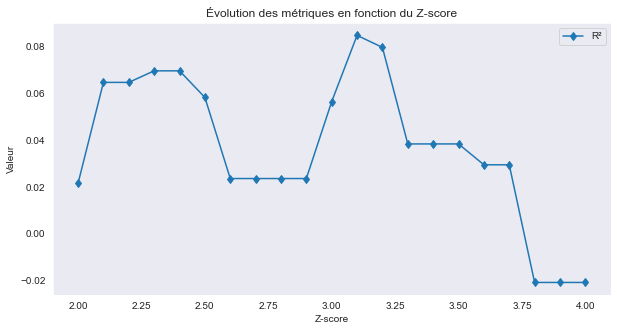

In [9]:
df = all_data.copy()

results = []

z_values = np.arange(2.0, 4.1, 0.1)

for z in z_values:
    df_filtered = df.copy()

    df_filtered['z_score'] = np.abs(zscore(df_filtered['duree_minutes']))

    lower_bound = df_filtered['duree_minutes'].mean() - z * df_filtered['duree_minutes'].std()
    upper_bound = df_filtered['duree_minutes'].mean() + z * df_filtered['duree_minutes'].std()

    total_before = len(df_filtered)

    df_filtered = df_filtered[df_filtered['z_score'] <= z].drop(columns=['z_score'])

    total_after = len(df_filtered)

    excluded_count = total_before - total_after
    excluded_percentage = (excluded_count / total_before) * 100

    hex_ids = df_filtered['hex_id'].unique()
    hex_train, hex_test = train_test_split(hex_ids, test_size=0.2, random_state=42)

    train_data = df_filtered[df_filtered['hex_id'].isin(hex_train)]
    test_data = df_filtered[df_filtered['hex_id'].isin(hex_test)]

    X_train, y_train = train_data.drop(columns=['duree_minutes', 'hex_id', 'geometry', 'centroid', 'date', 'departement']), train_data['duree_minutes']
    X_test, y_test = test_data.drop(columns=['duree_minutes', 'hex_id', 'geometry', 'centroid', 'date', 'departement']), test_data['duree_minutes']

    dtrain = DMatrix(X_train, label=y_train)
    dtest = DMatrix(X_test, label=y_test)

    params = {
        'objective': 'reg:squarederror',
        'eval_metric': 'rmse'
    }

    model = train(params, dtrain, num_boost_round=100, evals=[(dtest, "Test")], early_stopping_rounds=10, verbose_eval=False)

    y_pred = model.predict(dtest)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    results.append({'z': z, 'Lower Bound': lower_bound, 'Upper Bound': upper_bound,
                    'MAE': mae, 'RMSE': rmse, 'R2': r2,
                    'Excluded Count': excluded_count, 'Excluded Percentage': excluded_percentage})

results_df = pd.DataFrame(results)

print(results_df)

plt.figure(figsize=(10, 5))
plt.plot(results_df['z'], results_df['R2'], label="R²", marker='d')
plt.xlabel("Z-score")
plt.ylabel("Valeur")
plt.title("Évolution des métriques en fonction du Z-score")
plt.legend()
plt.grid()
plt.show()

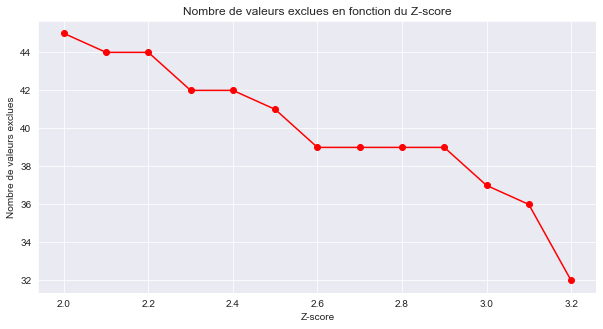

In [10]:
df = all_data.copy()

excluded_counts = []

z_values = np.arange(2.0, 3.2, 0.1)

for z in z_values:
    df_filtered = df.copy()

    df_filtered['z_score'] = np.abs(zscore(df_filtered['duree_minutes']))

    total_before = len(df_filtered)

    df_filtered = df_filtered[df_filtered['z_score'] <= z].drop(columns=['z_score'])

    total_after = len(df_filtered)

    excluded_count = total_before - total_after
    excluded_counts.append(excluded_count)

plt.figure(figsize=(10, 5))
plt.plot(z_values, excluded_counts, label="Nombre de valeurs exclues", marker='o', color='red')
plt.xlabel("Z-score")
plt.ylabel("Nombre de valeurs exclues")
plt.title("Nombre de valeurs exclues en fonction du Z-score")
plt.grid(True)
plt.show()

      z  Lower Bound  Upper Bound        MAE       RMSE        R2  \
0   2.0  -422.394899   601.022313  39.349242  58.707707  0.021522   
1   2.1  -447.980329   626.607743  39.085693  57.820369  0.064691   
2   2.2  -473.565759   652.193173  39.085693  57.820369  0.064691   
3   2.3  -499.151189   677.778604  37.802695  57.667296  0.069636   
4   2.4  -524.736620   703.364034  37.802695  57.667296  0.069636   
5   2.5  -550.322050   728.949464  38.641727  58.018904  0.058256   
6   2.6  -575.907480   754.534894  40.401395  59.078463  0.023546   
7   2.7  -601.492911   780.120325  40.401395  59.078463  0.023546   
8   2.8  -627.078341   805.705755  40.401395  59.078463  0.023546   
9   2.9  -652.663771   831.291185  40.401395  59.078463  0.023546   
10  3.0  -678.249201   856.876616  38.979651  58.074081  0.056464   
11  3.1  -703.834632   882.462046  39.778932  58.211628  0.084819   
12  3.2  -729.420062   908.047476  40.393201  64.665954  0.079663   
13  3.3  -755.005492   933.632906 

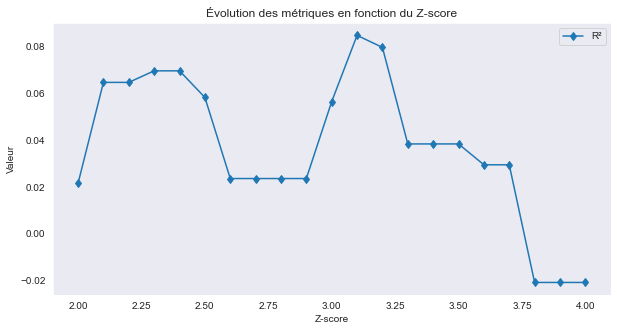

In [11]:
df = all_data.copy()

results = []

z_values = np.arange(2.0, 4.1, 0.1)

for z in z_values:
    df_filtered = df.copy()

    df_filtered['z_score'] = np.abs(zscore(df_filtered['duree_minutes']))

    lower_bound = df_filtered['duree_minutes'].mean() - z * df_filtered['duree_minutes'].std()
    upper_bound = df_filtered['duree_minutes'].mean() + z * df_filtered['duree_minutes'].std()

    total_before = len(df_filtered)

    df_filtered = df_filtered[df_filtered['z_score'] <= z].drop(columns=['z_score'])

    total_after = len(df_filtered)

    excluded_count = total_before - total_after
    excluded_percentage = (excluded_count / total_before) * 100

    hex_ids = df_filtered['hex_id'].unique()
    hex_train, hex_test = train_test_split(hex_ids, test_size=0.2, random_state=42)

    train_data = df_filtered[df_filtered['hex_id'].isin(hex_train)]
    test_data = df_filtered[df_filtered['hex_id'].isin(hex_test)]

    X_train, y_train = train_data.drop(columns=['duree_minutes', 'hex_id', 'geometry', 'centroid', 'date', 'departement']), train_data['duree_minutes']
    X_test, y_test = test_data.drop(columns=['duree_minutes', 'hex_id', 'geometry', 'centroid', 'date', 'departement']), test_data['duree_minutes']

    dtrain = DMatrix(X_train, label=y_train)
    dtest = DMatrix(X_test, label=y_test)

    params = {
        'objective': 'reg:squarederror',
        'eval_metric': 'rmse'
    }

    model = train(params, dtrain, num_boost_round=100, evals=[(dtest, "Test")], early_stopping_rounds=10, verbose_eval=False)

    y_pred = model.predict(dtest)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    results.append({'z': z, 'Lower Bound': lower_bound, 'Upper Bound': upper_bound,
                    'MAE': mae, 'RMSE': rmse, 'R2': r2,
                    'Excluded Count': excluded_count, 'Excluded Percentage': excluded_percentage})

results_df = pd.DataFrame(results)

print(results_df)

plt.figure(figsize=(10, 5))
plt.plot(results_df['z'], results_df['R2'], label="R²", marker='d')
plt.xlabel("Z-score")
plt.ylabel("Valeur")
plt.title("Évolution des métriques en fonction du Z-score")
plt.legend()
plt.grid()
plt.show()

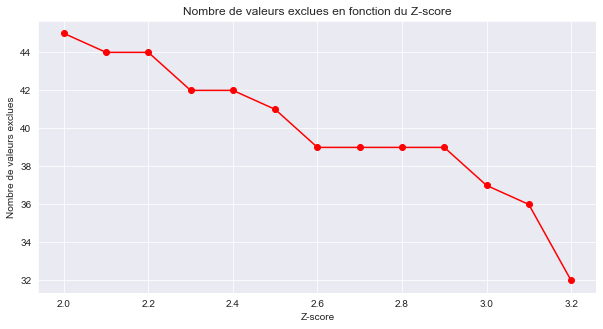

In [12]:
df = all_data.copy()

excluded_counts = []

z_values = np.arange(2.0, 3.2, 0.1)

for z in z_values:
    df_filtered = df.copy()

    df_filtered['z_score'] = np.abs(zscore(df_filtered['duree_minutes']))

    total_before = len(df_filtered)

    df_filtered = df_filtered[df_filtered['z_score'] <= z].drop(columns=['z_score'])

    total_after = len(df_filtered)

    excluded_count = total_before - total_after
    excluded_counts.append(excluded_count)

plt.figure(figsize=(10, 5))
plt.plot(z_values, excluded_counts, label="Nombre de valeurs exclues", marker='o', color='red')
plt.xlabel("Z-score")
plt.ylabel("Nombre de valeurs exclues")
plt.title("Nombre de valeurs exclues en fonction du Z-score")
plt.grid(True)
plt.show()

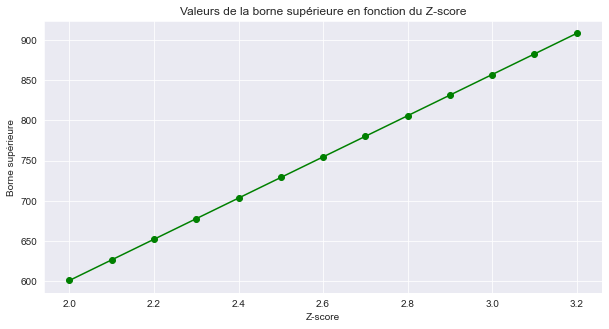

In [13]:
df = all_data.copy()

upper_bounds = []

z_values = np.arange(2.0, 3.2, 0.1)

for z in z_values:
    df['z_score'] = np.abs(zscore(df['duree_minutes']))

    upper_bound = df['duree_minutes'].mean() + z * df['duree_minutes'].std()

    upper_bounds.append(upper_bound)

plt.figure(figsize=(10, 5))
plt.plot(z_values, upper_bounds, label="Borne supérieure", marker='o', color='green')
plt.xlabel("Z-score")
plt.ylabel("Borne supérieure")
plt.title("Valeurs de la borne supérieure en fonction du Z-score")
plt.grid(True)
plt.show()

In [14]:
all_data['z_score'] = np.abs(zscore(all_data['duree_minutes']))

all_data_filtered = all_data[all_data['z_score'] <= 3.1].drop(columns=['z_score'])

values_removed = len(all_data) - len(all_data_filtered)
print(f"Nombre de valeurs supprimées : {values_removed}")
print(f"Pourcentage des données supprimées : {values_removed / len(all_data) * 100:.2f}%")

Nombre de valeurs supprimées : 36
Pourcentage des données supprimées : 0.47%


In [15]:
all_data_filtered['z_score'] = zscore(all_data_filtered['duree_minutes'])

threshold = 2.9

excluded_values = all_data_filtered[(all_data_filtered['z_score'] > threshold) | (all_data_filtered['z_score'] < -threshold)]

num_excluded = excluded_values.shape[0]

lower_limit = -threshold
upper_limit = threshold

print(f"Nombre de valeurs exclues : {num_excluded}")
print(f"Seuils de z-score : {lower_limit} et {upper_limit}")

Nombre de valeurs exclues : 162
Seuils de z-score : -2.9 et 2.9


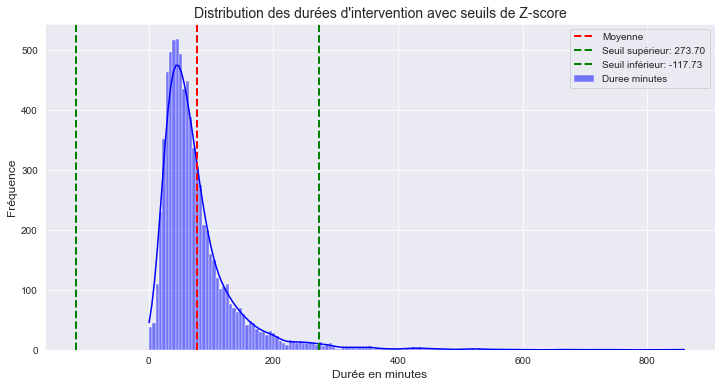

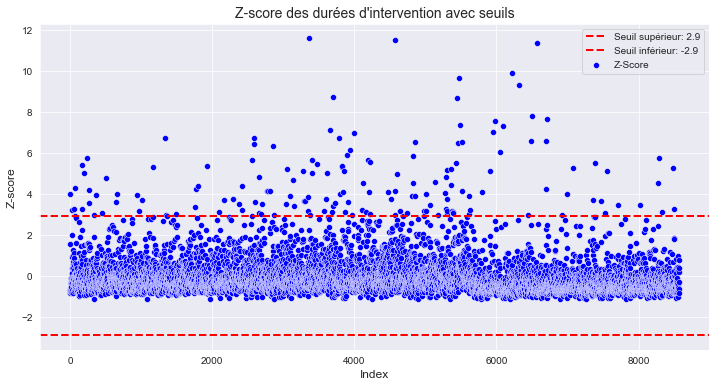

Valeur limite pour le seuil supérieur (z-score = 2.9): 273.70
Valeur limite pour le seuil inférieur (z-score = -2.9): -117.73


In [16]:
mean_duree = all_data_filtered['duree_minutes'].mean()
std_duree = all_data_filtered['duree_minutes'].std()

upper_limit_value = mean_duree + threshold * std_duree
lower_limit_value = mean_duree - threshold * std_duree

plt.figure(figsize=(12, 6))

sns.histplot(all_data_filtered['duree_minutes'], kde=True, color='blue', label='Duree minutes')
plt.axvline(mean_duree, color='red', linestyle='dashed', linewidth=2, label='Moyenne')
plt.axvline(upper_limit_value, color='green', linestyle='dashed', linewidth=2, label=f'Seuil supérieur: {upper_limit_value:.2f}')
plt.axvline(lower_limit_value, color='green', linestyle='dashed', linewidth=2, label=f'Seuil inférieur: {lower_limit_value:.2f}')

plt.title('Distribution des durées d\'intervention avec seuils de Z-score', fontsize=14)
plt.xlabel('Durée en minutes', fontsize=12)
plt.ylabel('Fréquence', fontsize=12)
plt.legend()

plt.show()

plt.figure(figsize=(12, 6))

sns.scatterplot(x=all_data_filtered.index, y=all_data_filtered['z_score'], color='blue', label='Z-Score')

plt.axhline(y=threshold, color='red', linestyle='dashed', linewidth=2, label=f'Seuil supérieur: {threshold}')
plt.axhline(y=-threshold, color='red', linestyle='dashed', linewidth=2, label=f'Seuil inférieur: {-threshold}')

plt.title('Z-score des durées d\'intervention avec seuils', fontsize=14)
plt.xlabel('Index', fontsize=12)
plt.ylabel('Z-score', fontsize=12)
plt.legend()

plt.show()

print(f"Valeur limite pour le seuil supérieur (z-score = {threshold}): {upper_limit_value:.2f}")
print(f"Valeur limite pour le seuil inférieur (z-score = {-threshold}): {lower_limit_value:.2f}")

In [17]:
all_data_final = all_data_filtered[(all_data_filtered['z_score'] <= threshold) & (all_data_filtered['z_score'] >= -threshold)]

In [18]:
duplicates = all_data_final.duplicated()

nb_duplicates = duplicates.sum()

print(f"Nombre de lignes dupliquées : {nb_duplicates}")

if nb_duplicates > 0:
    display(all_data_final[duplicates])

Nombre de lignes dupliquées : 0


In [19]:
all_data_final["dep_sum_duree"] = all_data_final.groupby(["date", "departement"])["duree_minutes"].transform("sum")


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


In [20]:
all_data_final["pop_x_route"] = all_data_final["population"] * (all_data_final["motorway"] + all_data_final["primary"] + all_data_final["secondary"] + all_data_final["tertiary"])

all_data_final["NDVI_NDMI"] = all_data_final["NDVI"] * all_data_final["NDMI"]
all_data_final["NDWI_NDSI"] = all_data_final["NDWI"] * all_data_final["NDSI"]

all_data_final["elev_x_foret"] = all_data_final["elevation"] * all_data_final["foret_encoder"]

all_data_final["log_population"] = np.log1p(all_data_final["population"])
all_data_final["sqrt_elevation"] = np.sqrt(all_data_final["elevation"])

all_data_final["hour_sin"] = np.sin(2 * np.pi * all_data_final["hour"] / 24)
all_data_final["hour_cos"] = np.cos(2 * np.pi * all_data_final["hour"] / 24)
all_data_final["month_sin"] = np.sin(2 * np.pi * all_data_final["month"] / 12)
all_data_final["month_cos"] = np.cos(2 * np.pi * all_data_final["month"] / 12)
all_data_final["weekday_sin"] = np.sin(2 * np.pi * all_data_final["weekday"] / 7)
all_data_final["weekday_cos"] = np.cos(2 * np.pi * all_data_final["weekday"] / 7)

all_data_final = all_data_final.sort_values(by=["hex_id", "date"])

all_data_final["mean_duree_hex_7j"] = all_data_final.groupby("hex_id")["duree_minutes"].rolling(7, min_periods=1).mean().reset_index(drop=True)

all_data_final["std_duree_hex_7j"] = all_data_final.groupby("hex_id")["duree_minutes"].rolling(7, min_periods=1).std().reset_index(drop=True)


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/

In [21]:
print(all_data_final.isna().sum())

hex_id                  0
year                    0
date                    0
departement             0
duree_minutes           0
                     ... 
month_cos               0
weekday_sin             0
weekday_cos             0
mean_duree_hex_7j     968
std_duree_hex_7j     2440
Length: 71, dtype: int64


In [22]:
all_data_final["mean_duree_hex_7j"] = (
    all_data_final.groupby("hex_id")["duree_minutes"]
    .rolling(7, min_periods=1)
    .mean()
    .reset_index(level=0, drop=True)
)

all_data_final["std_duree_hex_7j"] = (
    all_data_final.groupby("hex_id")["duree_minutes"]
    .rolling(7, min_periods=1)
    .std()
    .reset_index(level=0, drop=True)
)

In [23]:
all_data_final[["mean_duree_hex_7j", "std_duree_hex_7j"]] = all_data_final[["mean_duree_hex_7j", "std_duree_hex_7j"]].fillna(0)

In [24]:
print(all_data_final.isna().sum())

hex_id               0
year                 0
date                 0
departement          0
duree_minutes        0
                    ..
month_cos            0
weekday_sin          0
weekday_cos          0
mean_duree_hex_7j    0
std_duree_hex_7j     0
Length: 71, dtype: int64


In [25]:
print(all_data_final["hex_id"].nunique())
print(all_data_final.groupby("hex_id")["duree_minutes"].count().value_counts())

1683
1     533
2     347
3     214
4     154
5      82
6      69
7      51
9      35
10     31
8      31
11     19
15     12
12     11
13      9
14      8
16      7
19      6
20      6
17      4
18      4
22      4
23      4
30      4
25      3
27      3
28      3
40      2
39      2
32      2
29      2
21      2
26      2
35      2
24      2
59      1
49      1
73      1
31      1
37      1
44      1
67      1
34      1
50      1
41      1
43      1
54      1
38      1
Name: duree_minutes, dtype: int64


In [26]:
print(all_data_final["duree_minutes"].isna().sum())

0


In [27]:
all_data_final.head()

,hex_id,year,date,departement,duree_minutes,geometry,centroid,centroid_lon,centroid_lat,hour,...,log_population,sqrt_elevation,hour_sin,hour_cos,month_sin,month_cos,weekday_sin,weekday_cos,mean_duree_hex_7j,std_duree_hex_7j
247,871f80492ffffff,2015.0,2015-07-18,departement-25-doubs,40.850000,"POLYGON ((6.33348 47.48111, 6.33537 47.46913, ...",POINT (6.35020 47.47708),6.350198,47.477082,18,...,3.218877,12.09992,-1.000000,-1.836970e-16,-0.500000,-8.660254e-01,-0.974928,-0.222521,40.850000,0.000000
801,871f80492ffffff,2017.0,2017-08-07,departement-25-doubs,197.783333,"POLYGON ((6.33348 47.48111, 6.33537 47.46913, ...",POINT (6.35020 47.47708),6.350198,47.477082,17,...,3.218877,12.09992,-0.965926,-2.588190e-01,-0.866025,-5.000000e-01,0.000000,1.000000,119.316667,110.968624
1401,871f80492ffffff,2019.0,2019-04-02,departement-25-doubs,163.133333,"POLYGON ((6.33348 47.48111, 6.33537 47.46913, ...",POINT (6.35020 47.47708),6.350198,47.477082,15,...,3.218877,12.09992,-0.707107,-7.071068e-01,0.866025,-5.000000e-01,0.781831,0.623490,133.922222,82.443827
1580,871f80492ffffff,2019.0,2019-07-23,departement-25-doubs,168.250000,"POLYGON ((6.33348 47.48111, 6.33537 47.46913, ...",POINT (6.35020 47.47708),6.350198,47.477082,10,...,3.218877,12.09992,0.500000,-8.660254e-01,-0.500000,-8.660254e-01,0.781831,0.623490,142.504167,69.468857
2379,871f80492ffffff,2022.0,2022-03-04,departement-25-doubs,61.850000,"POLYGON ((6.33348 47.48111, 6.33537 47.46913, ...",POINT (6.35020 47.47708),6.350198,47.477082,18,...,3.218877,12.09992,-1.000000,-1.836970e-16,1.000000,6.123234e-17,-0.433884,-0.900969,126.373333,70.145994


In [28]:
intervention_counts = all_data_final.groupby(["date", "departement"]).size()

distribution = intervention_counts.value_counts().sort_index()

for nb_interventions, nb_jours in distribution.items():
    print(f"Nombre de journées avec {nb_interventions} intervention(s) dans le département : {nb_jours}")

Nombre de journées avec 1 intervention(s) dans le département : 1657
Nombre de journées avec 2 intervention(s) dans le département : 833
Nombre de journées avec 3 intervention(s) dans le département : 396
Nombre de journées avec 4 intervention(s) dans le département : 234
Nombre de journées avec 5 intervention(s) dans le département : 137
Nombre de journées avec 6 intervention(s) dans le département : 70
Nombre de journées avec 7 intervention(s) dans le département : 36
Nombre de journées avec 8 intervention(s) dans le département : 24
Nombre de journées avec 9 intervention(s) dans le département : 15
Nombre de journées avec 10 intervention(s) dans le département : 10
Nombre de journées avec 11 intervention(s) dans le département : 6
Nombre de journées avec 12 intervention(s) dans le département : 5
Nombre de journées avec 13 intervention(s) dans le département : 1
Nombre de journées avec 14 intervention(s) dans le département : 3
Nombre de journées avec 15 intervention(s) dans le dépa

In [29]:
hex_ids = all_data_final['hex_id'].unique()
np.random.seed(42)
np.random.shuffle(hex_ids)

split_index = int(len(hex_ids) * 0.7)
hex_train_ids = set(hex_ids[:split_index])
hex_test_ids = set(hex_ids[split_index:])

assert hex_train_ids.isdisjoint(hex_test_ids), "Erreur : Un hex_id est présent dans les deux sets !"

all_train = all_data_final[all_data_final['hex_id'].isin(hex_train_ids)].copy()
all_test = all_data_final[all_data_final['hex_id'].isin(hex_test_ids)].copy()

print(f"Taille de all_train : {all_train.shape}")
print(f"Taille de all_test : {all_test.shape}")
print(f"Hex_id uniques dans all_train : {all_train['hex_id'].nunique()}")
print(f"Hex_id uniques dans all_test : {all_test['hex_id'].nunique()}")

intersection = set(all_train['hex_id']).intersection(set(all_test['hex_id']))
assert len(intersection) == 0, f"Problème : {len(intersection)} hex_id sont communs entre all_train et all_test !"

Taille de all_train : (5059, 71)
Taille de all_test : (2368, 71)
Hex_id uniques dans all_train : 1178
Hex_id uniques dans all_test : 505


In [30]:
hex_train_ids = set(all_train['hex_id'])
hex_test_ids = set(all_test['hex_id'])

hex_communs = hex_train_ids.intersection(hex_test_ids)

if hex_communs:
    print(f"Il y a {len(hex_communs)} hex_id communs entre all_train et all_test.")
    print(f"Hex_id communs : {hex_communs}")
else:
    print("Aucun hex_id n'est commun entre all_train et all_test.")

Aucun hex_id n'est commun entre all_train et all_test.


In [31]:
colonnes_a_exclure = ['hex_id', 'geometry', 'centroid', 'hex_voisins', 'duree_minutes', 'z_score', "dep_sum_duree", "date", "year"]

features = [col for col in all_train.columns if col not in colonnes_a_exclure]

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), ['departement']),
        ('num', StandardScaler(), [col for col in features if col != 'departement'])
    ]
)

X_train = all_train[features]
y_train = all_train["dep_sum_duree"]
X_test = all_test[features]
y_test = all_test["dep_sum_duree"]

X_train_preprocessed = preprocessor.fit_transform(X_train)
X_test_preprocessed = preprocessor.transform(X_test)

models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'XGBoost': XGBRegressor(objective='reg:squarederror', n_estimators=100, random_state=42),
    'LightGBM':  LGBMRegressor(n_estimators=100, random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train_preprocessed, y_train)

    y_pred = model.predict(X_test_preprocessed)

    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    results[name] = {'MSE': mse, 'MAE': mae, 'RMSE': rmse, 'R^2': r2, 'predictions': y_pred}

for name, metrics in results.items():
    print(f"{name}: MSE = {metrics['MSE']:.4f}, MAE = {metrics['MAE']:.4f}, RMSE = {metrics['RMSE']:.4f}, R^2 = {metrics['R^2']:.4f}")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005093 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 9910
[LightGBM] [Info] Number of data points in the train set: 5059, number of used features: 61
[LightGBM] [Info] Start training from score 256.747984
Linear Regression: MSE = 48604.4020, MAE = 155.9016, RMSE = 220.4641, R^2 = 0.1210
Random Forest: MSE = 44889.3237, MAE = 152.0693, RMSE = 211.8710, R^2 = 0.1882
Gradient Boosting: MSE = 45000.8390, MAE = 147.4401, RMSE = 212.1340, R^2 = 0.1862
XGBoost: MSE = 47800.4883, MAE = 155.8540, RMSE = 218.6332, R^2 = 0.1356
LightGBM: MSE = 44490.4892, MAE = 147.6347, RMSE = 210.9277, R^2 = 0.1954


FixedFormatter should only be used together with FixedLocator


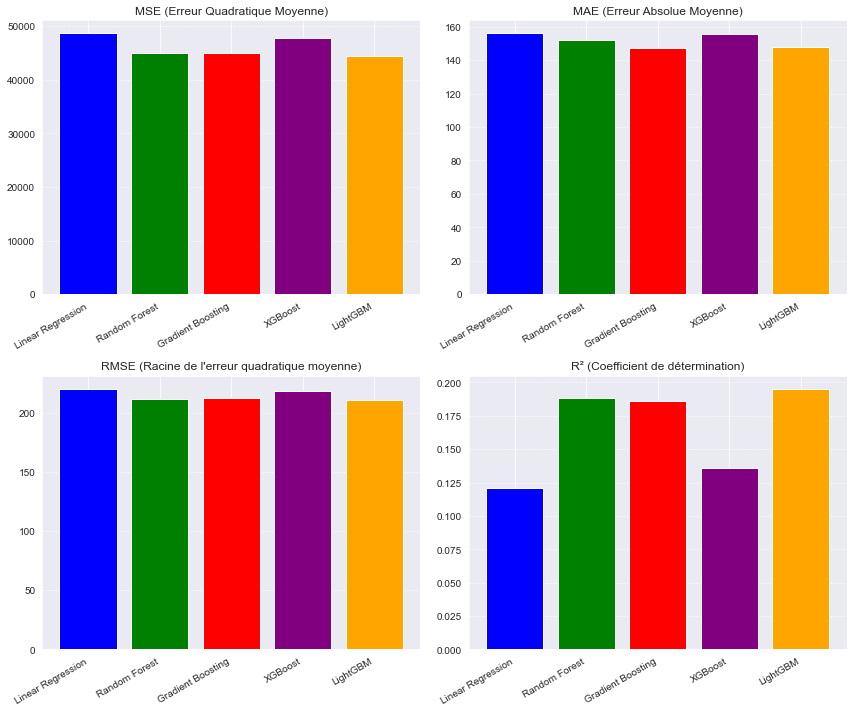

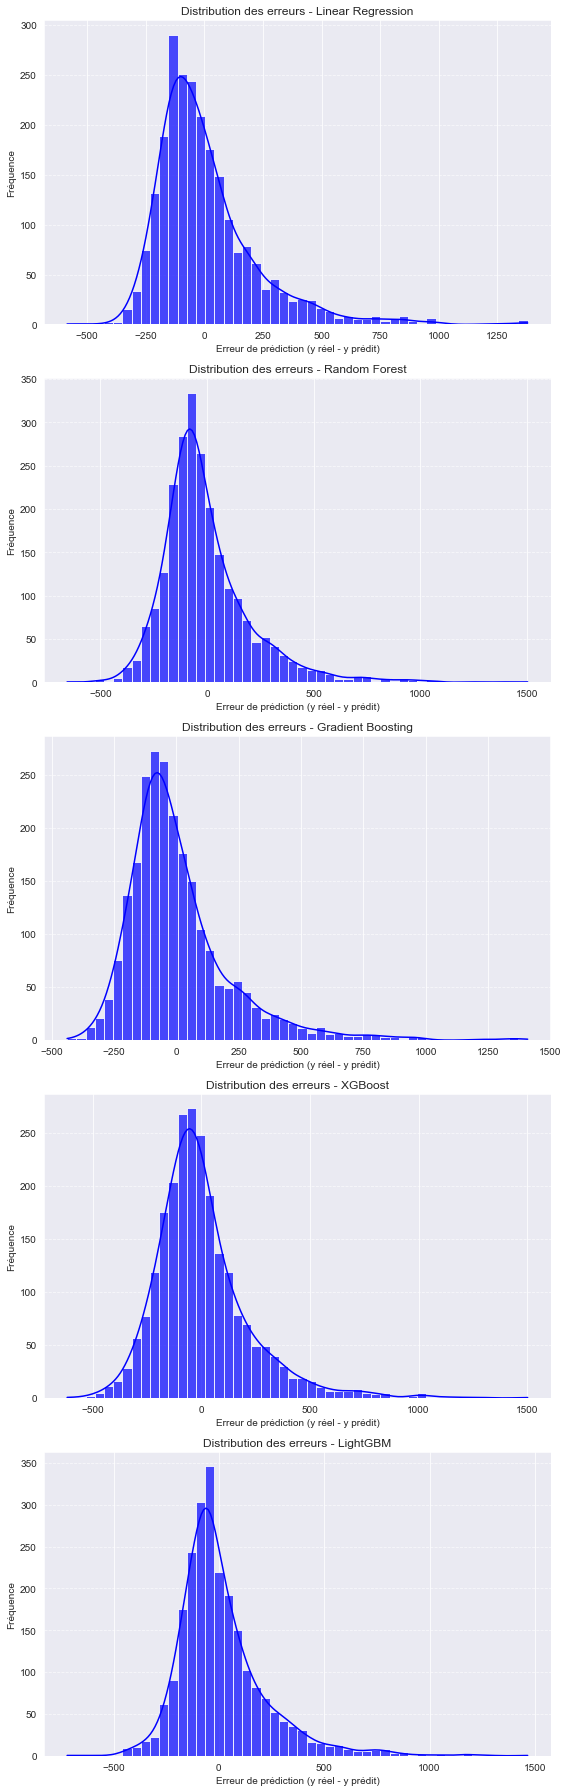

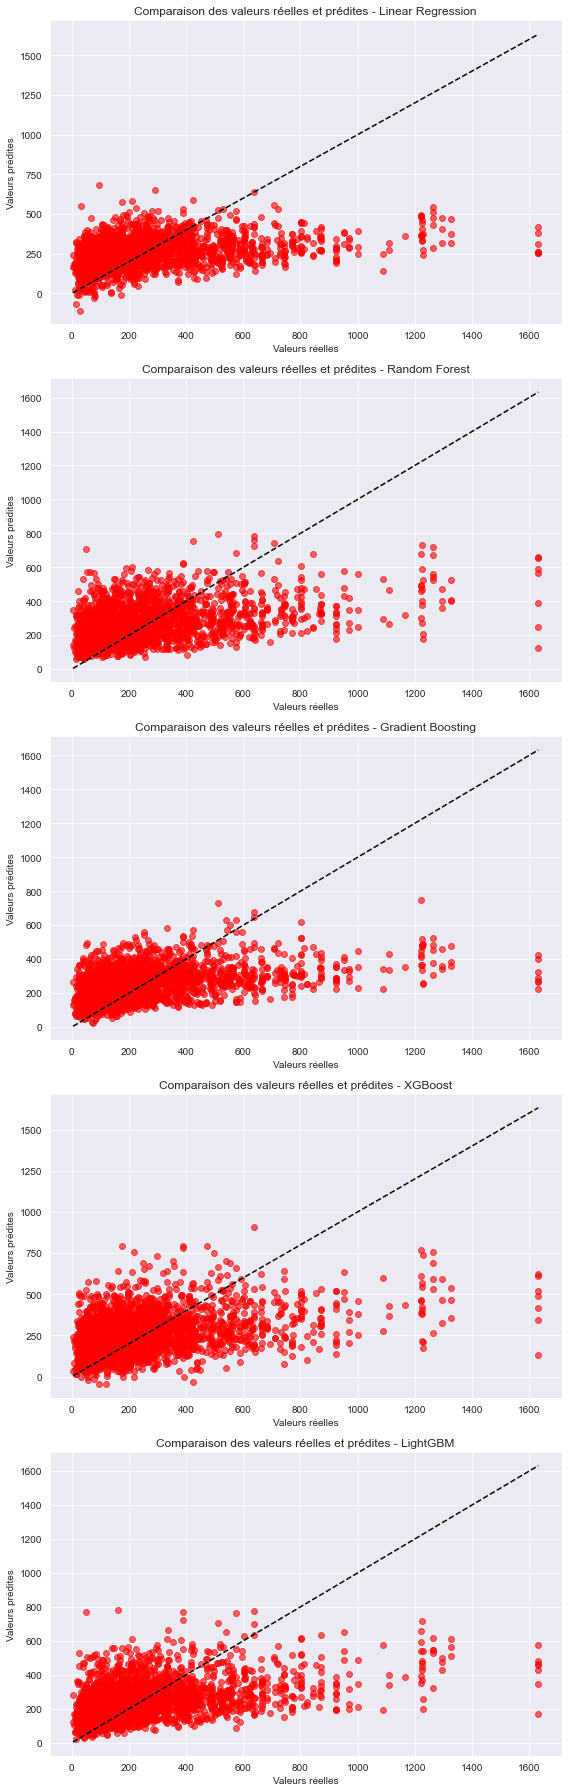

In [32]:
model_names = list(results.keys())
mse_values = [results[m]["MSE"] for m in model_names]
mae_values = [results[m]["MAE"] for m in model_names]
rmse_values = [results[m]["RMSE"] for m in model_names]
r2_values = [results[m]["R^2"] for m in model_names]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
metrics = [mse_values, mae_values, rmse_values, r2_values]
titles = ["MSE (Erreur Quadratique Moyenne)", "MAE (Erreur Absolue Moyenne)",
          "RMSE (Racine de l'erreur quadratique moyenne)", "R² (Coefficient de détermination)"]

for i, ax in enumerate(axes.flat):
    ax.bar(model_names, metrics[i], color=['blue', 'green', 'red', 'purple', 'orange'])
    ax.set_title(titles[i])
    ax.set_xticklabels(model_names, rotation=30, ha="right")
    ax.grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(len(model_names), 1, figsize=(8, 5 * len(model_names)))

for i, model in enumerate(model_names):
    ax = axes[i] if len(model_names) > 1 else axes
    residuals = y_test - results[model]["predictions"]
    sns.histplot(residuals, bins=50, kde=True, alpha=0.7, ax=ax, color='blue')

    ax.set_title(f"Distribution des erreurs - {model}")
    ax.set_xlabel("Erreur de prédiction (y réel - y prédit)")
    ax.set_ylabel("Fréquence")
    ax.grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(len(model_names), 1, figsize=(8, 5 * len(model_names)))

for i, model in enumerate(model_names):
    ax = axes[i] if len(model_names) > 1 else axes
    ax.scatter(y_test, results[model]["predictions"], alpha=0.6, color='red')

    ax.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color="black", linestyle="--")
    ax.set_xlabel("Valeurs réelles")
    ax.set_ylabel("Valeurs prédites")
    ax.set_title(f"Comparaison des valeurs réelles et prédites - {model}")
    ax.grid(True)

plt.tight_layout()
plt.show()

In [33]:
mean_y_test = y_test.mean()
std_y_test = y_test.std()
baseline_mae = abs(y_test - mean_y_test).mean()

print(f"Moyenne des valeurs réelles : {mean_y_test:.2f}")
print(f"Écart-type des valeurs réelles : {std_y_test:.2f}")
print(f"MAE d'une prédiction naïve (moyenne) : {baseline_mae:.2f}")
print("-" * 50)

for model in model_names:
    model_mae = results[model]["MAE"]
    print(f"{model} - MAE : {model_mae:.2f} (baseline : {baseline_mae:.2f})")

    if model_mae < baseline_mae:
        print("Ce modèle fait mieux que la prédiction naïve.")
    else:
        print("Ce modèle ne fait pas mieux qu'une prédiction basique.")
    print("-" * 50)

Moyenne des valeurs réelles : 258.93
Écart-type des valeurs réelles : 235.20
MAE d'une prédiction naïve (moyenne) : 169.82
--------------------------------------------------
Linear Regression - MAE : 155.90 (baseline : 169.82)
Ce modèle fait mieux que la prédiction naïve.
--------------------------------------------------
Random Forest - MAE : 152.07 (baseline : 169.82)
Ce modèle fait mieux que la prédiction naïve.
--------------------------------------------------
Gradient Boosting - MAE : 147.44 (baseline : 169.82)
Ce modèle fait mieux que la prédiction naïve.
--------------------------------------------------
XGBoost - MAE : 155.85 (baseline : 169.82)
Ce modèle fait mieux que la prédiction naïve.
--------------------------------------------------
LightGBM - MAE : 147.63 (baseline : 169.82)
Ce modèle fait mieux que la prédiction naïve.
--------------------------------------------------


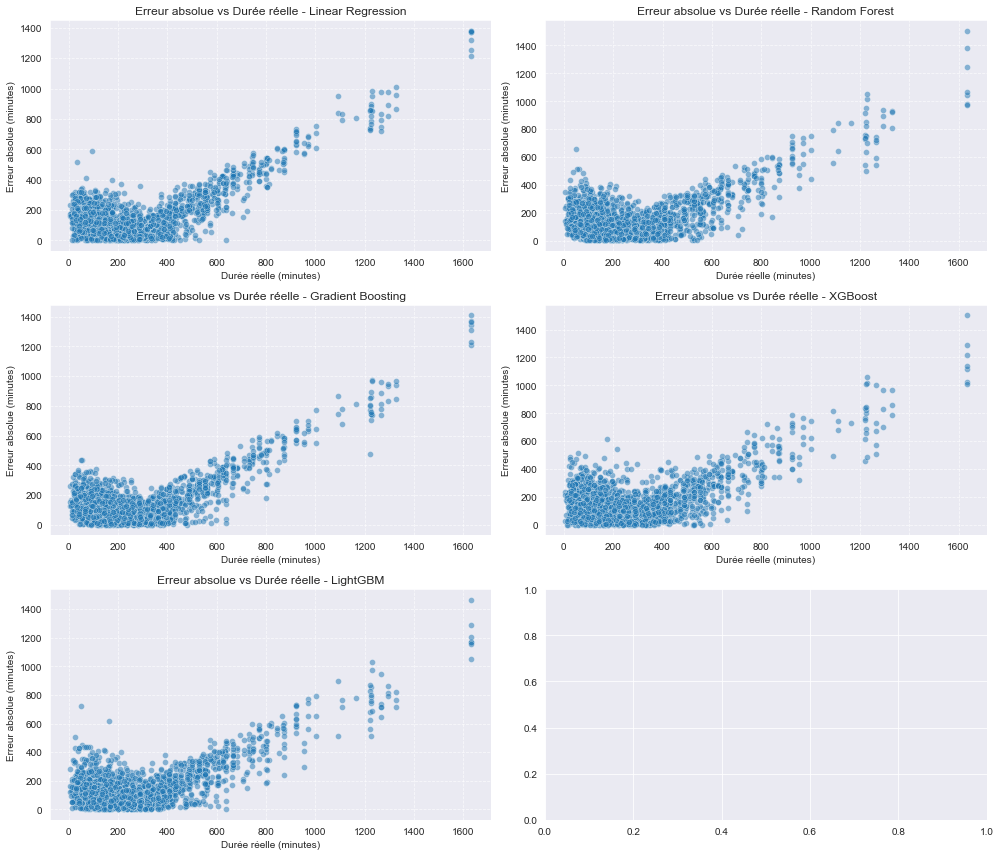

In [34]:
fig, axes = plt.subplots(3, 2, figsize=(14, 12))
axes = axes.flatten()

for i, model in enumerate(results.keys()):
    errors = np.abs(y_test - results[model]["predictions"])
    sns.scatterplot(x=y_test, y=errors, alpha=0.5, ax=axes[i])
    axes[i].set_title(f"Erreur absolue vs Durée réelle - {model}")
    axes[i].set_xlabel("Durée réelle (minutes)")
    axes[i].set_ylabel("Erreur absolue (minutes)")
    axes[i].grid(True, linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()

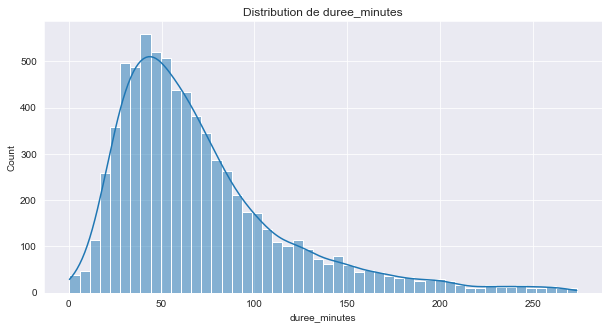

In [35]:
plt.figure(figsize=(10,5))
sns.histplot(all_data_final["duree_minutes"], bins=50, kde=True)
plt.title("Distribution de duree_minutes")
plt.show()

In [36]:
"""param_grid = {
    'num_leaves': [31, 50, 70, 100],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'n_estimators': [500, 1000],
    'max_depth': [15, 20, -1],
    'min_child_samples': [5, 10, 20]
}

grid_search = GridSearchCV(LGBMRegressor(), param_grid, cv=3, scoring="r2", verbose=2, n_jobs=-1)
grid_search.fit(X_train_preprocessed, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best R² Score:", grid_search.best_score_)"""

'param_grid = {\n    \'num_leaves\': [31, 50, 70, 100],\n    \'learning_rate\': [0.01, 0.05, 0.1, 0.2],\n    \'n_estimators\': [500, 1000],\n    \'max_depth\': [15, 20, -1],\n    \'min_child_samples\': [5, 10, 20]\n}\n\ngrid_search = GridSearchCV(LGBMRegressor(), param_grid, cv=3, scoring="r2", verbose=2, n_jobs=-1)\ngrid_search.fit(X_train_preprocessed, y_train)\n\nprint("Best Parameters:", grid_search.best_params_)\nprint("Best R² Score:", grid_search.best_score_)'

In [37]:
"""Best Parameters: {'learning_rate': 0.01, 'max_depth': 10, 'min_child_samples': 30, 'n_estimators': 500, 'num_leaves': 31}"""

"Best Parameters: {'learning_rate': 0.01, 'max_depth': 10, 'min_child_samples': 30, 'n_estimators': 500, 'num_leaves': 31}"

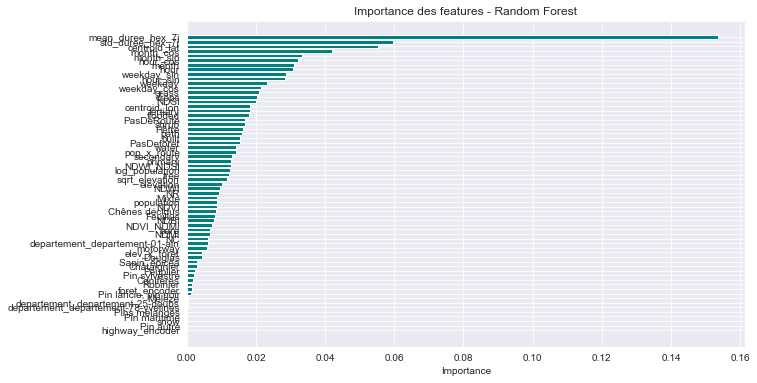


Random Forest - Importance des Features :
              Feature  Importance
63  mean_duree_hex_7j    0.153673
64   std_duree_hex_7j    0.059646
4        centroid_lat    0.055211
60          month_cos    0.042078
59          month_sin    0.033190
58           hour_cos    0.032290
6               month    0.030944
5                hour    0.030664
61        weekday_sin    0.028784
57           hour_sin    0.028379


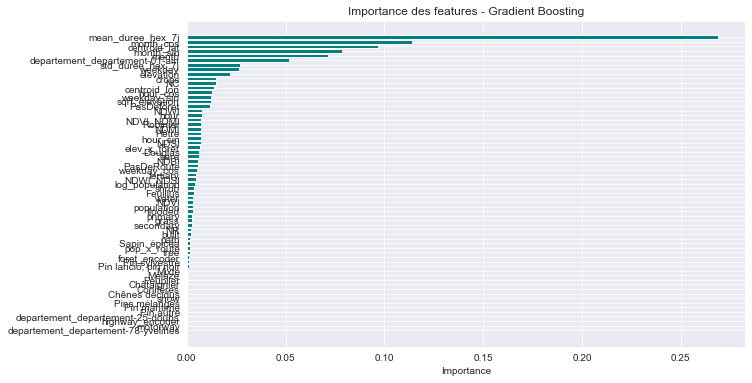


Gradient Boosting - Importance des Features :
                           Feature  Importance
63               mean_duree_hex_7j    0.268947
60                       month_cos    0.114143
4                     centroid_lat    0.096622
59                       month_sin    0.078351
6                            month    0.071437
0   departement_departement-01-ain    0.051568
64                std_duree_hex_7j    0.026985
7                          weekday    0.026268
20                       elevation    0.021841
45                           crops    0.014907


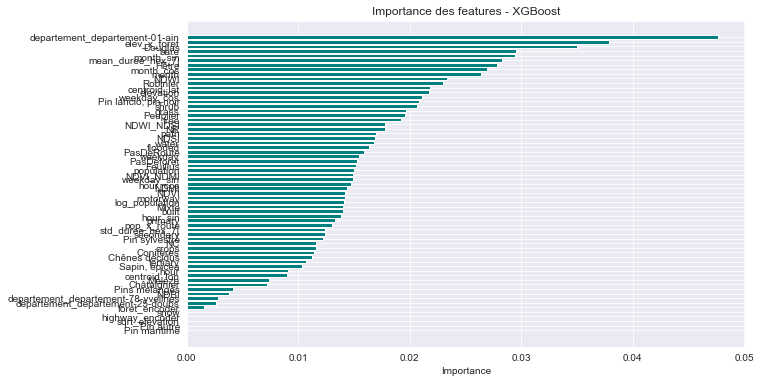


XGBoost - Importance des Features :
                           Feature  Importance
0   departement_departement-01-ain    0.047669
54                    elev_x_foret    0.037835
27                         Douglas    0.035033
49                            bare    0.029511
59                       month_sin    0.029445
63               mean_duree_hex_7j    0.028279
29                           Hêtre    0.027799
60                       month_cos    0.026885
6                            month    0.026403
12                            NDWI    0.023376
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002278 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 9910
[LightGBM] [Info] Number of data points in the train set: 5059, number of used features: 61
[LightGBM] [Info] Start training from score 256.747984


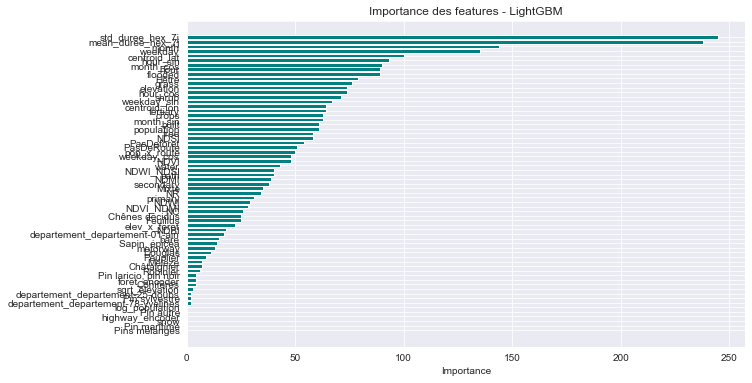


LightGBM - Importance des Features :
              Feature  Importance
64   std_duree_hex_7j         245
63  mean_duree_hex_7j         238
6               month         144
7             weekday         135
4        centroid_lat         100
57           hour_sin          93
60          month_cos          90
5                hour          89
47            flooded          89
29              Hêtre          79

--- Résultats des modèles ---
Linear Regression: MSE = 48604.4020, MAE = 155.9016, RMSE = 220.4641, R^2 = 0.1210
Random Forest: MSE = 44889.3237, MAE = 152.0693, RMSE = 211.8710, R^2 = 0.1882
Gradient Boosting: MSE = 45000.8390, MAE = 147.4401, RMSE = 212.1340, R^2 = 0.1862
XGBoost: MSE = 47800.4883, MAE = 155.8540, RMSE = 218.6332, R^2 = 0.1356
LightGBM: MSE = 44490.4892, MAE = 147.6347, RMSE = 210.9277, R^2 = 0.1954

--- Importances des Features ---

Linear Regression - Importances des Features :
None

Random Forest - Importances des Features :
              Feature  Importance


In [38]:
def get_feature_names(preprocessor, X):
    column_names = []
    for name, trans, columns in preprocessor.transformers_:
        if isinstance(trans, OneHotEncoder):
            column_names.extend(trans.get_feature_names_out(columns))
        else:
            column_names.extend(columns)
    return column_names

features_transformed = get_feature_names(preprocessor, X_train)

def plot_feature_importance(model, features, model_name):
    if hasattr(model, 'feature_importances_'):
        importance = model.feature_importances_
        importance_df = pd.DataFrame({
            'Feature': features,
            'Importance': importance
        })

        importance_df = importance_df.sort_values(by='Importance', ascending=False)

        plt.figure(figsize=(10, 6))
        plt.barh(importance_df['Feature'], importance_df['Importance'], color='teal')
        plt.xlabel('Importance')
        plt.title(f'Importance des features - {model_name}')
        plt.gca().invert_yaxis()
        plt.show()

        print(f"\n{model_name} - Importance des Features :")
        print(importance_df.head(10))

        return importance_df

results = {}
importance_results = {}

for name, model in models.items():
    model.fit(X_train_preprocessed, y_train)

    y_pred = model.predict(X_test_preprocessed)

    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    results[name] = {'MSE': mse, 'MAE': mae, 'RMSE': rmse, 'R^2': r2, 'predictions': y_pred}

    importance_results[name] = plot_feature_importance(model, features_transformed, name)

print("\n--- Résultats des modèles ---")
for name, metrics in results.items():
    print(f"{name}: MSE = {metrics['MSE']:.4f}, MAE = {metrics['MAE']:.4f}, RMSE = {metrics['RMSE']:.4f}, R^2 = {metrics['R^2']:.4f}")

print("\n--- Importances des Features ---")
for name, importance_df in importance_results.items():
    print(f"\n{name} - Importances des Features :")
    print(importance_df)

In [39]:
unique_hex_ids = all_data_final['hex_id'].unique()
np.random.seed(42)
np.random.shuffle(unique_hex_ids)

train_hex, temp_hex = train_test_split(unique_hex_ids, test_size=0.30, random_state=42)
valid_hex, test_hex = train_test_split(temp_hex, test_size=0.50, random_state=42)

esg_train = all_data_final[all_data_final['hex_id'].isin(train_hex)]
esg_valid = all_data_final[all_data_final['hex_id'].isin(valid_hex)]
esg_test = all_data_final[all_data_final['hex_id'].isin(test_hex)]

print(f"Train: {len(esg_train)} ({len(esg_train) / len(all_data_final) * 100:.1f}%)")
print(f"Validation: {len(esg_valid)} ({len(esg_valid) / len(all_data_final) * 100:.1f}%)")
print(f"Test: {len(esg_test)} ({len(esg_test) / len(all_data_final) * 100:.1f}%)")

Train: 5406 (72.8%)
Validation: 964 (13.0%)
Test: 1057 (14.2%)


In [40]:
colonnes_a_exclure = ['hex_id', 'geometry', 'centroid', 'hex_voisins', 'year', 'duree_minutes', 'z_score', "dep_sum_duree", "date"]

features = [col for col in all_data_final.columns if col not in colonnes_a_exclure]

X_train, y_train = esg_train[features], esg_train["dep_sum_duree"]
X_valid, y_valid = esg_valid[features], esg_valid["dep_sum_duree"]
X_test, y_test = esg_test[features], esg_test["dep_sum_duree"]

print(f"Features utilisées : {features}")

Features utilisées : ['departement', 'centroid_lon', 'centroid_lat', 'hour', 'month', 'weekday', 'NDVI', 'NDMI', 'NDBI', 'NDSI', 'NDWI', 'PasDeRoute', 'motorway', 'primary', 'secondary', 'tertiary', 'path', 'population', 'elevation', 'foret_encoder', 'highway_encoder', 'PasDeforet', 'Châtaignier', 'Chênes décidus', 'Conifères', 'Douglas', 'Feuillus', 'Hêtre', 'Mixte', 'Mélèze', 'NC', 'NR', 'Peuplier', 'Pin autre', 'Pin laricio, pin noir', 'Pin maritime', 'Pin sylvestre', 'Pins mélangés', 'Robinier', 'Sapin, épicéa', 'water', 'tree', 'grass', 'crops', 'shrub', 'flooded', 'built', 'bare', 'snow', 'pop_x_route', 'NDVI_NDMI', 'NDWI_NDSI', 'elev_x_foret', 'log_population', 'sqrt_elevation', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'weekday_sin', 'weekday_cos', 'mean_duree_hex_7j', 'std_duree_hex_7j']


In [41]:
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), ['departement']),
        ('num', StandardScaler(), [col for col in features if col != 'departement'])
    ]
)

X_train_preprocessed = preprocessor.fit_transform(X_train)
X_valid_preprocessed = preprocessor.transform(X_valid)
X_test_preprocessed = preprocessor.transform(X_test)

In [42]:
train_dataset = Dataset(X_train_preprocessed, label=y_train)
valid_dataset = Dataset(X_valid_preprocessed, label=y_valid, reference=train_dataset)

model = LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.03,
    num_leaves=40,
    min_data_in_leaf=15,
    lambda_l1=1.0,
    lambda_l2=1.0,
    random_state=42
)

model.fit(
    X_train_preprocessed, y_train,
    eval_set=[(X_valid_preprocessed, y_valid)],
    eval_metric='rmse',
    callbacks=[early_stopping(stopping_rounds=10, verbose=True)],
)

y_pred = model.predict(X_test_preprocessed)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Performance finale :")
print(f"MSE = {mse:.4f}, MAE = {mae:.4f}, RMSE = {rmse:.4f}, R^2 = {r2:.4f}")

[LightGBM] [Warning] lambda_l1 is set=1.0, reg_alpha=0.0 will be ignored. Current value: lambda_l1=1.0
[LightGBM] [Warning] lambda_l2 is set=1.0, reg_lambda=0.0 will be ignored. Current value: lambda_l2=1.0
[LightGBM] [Warning] min_data_in_leaf is set=15, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=15
[LightGBM] [Warning] lambda_l1 is set=1.0, reg_alpha=0.0 will be ignored. Current value: lambda_l1=1.0
[LightGBM] [Warning] lambda_l2 is set=1.0, reg_lambda=0.0 will be ignored. Current value: lambda_l2=1.0
[LightGBM] [Warning] min_data_in_leaf is set=15, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=15
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004197 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 9939
[LightGBM] [Info] Number of data points in the train set: 5406, number of used features: 61
[LightGBM] [Warning] lambda_l1 is set=1.0, reg_alpha=0

In [43]:
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), ['departement']),
        ('num', StandardScaler(), [col for col in X_train.columns if col != 'departement'])
    ]
)

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'num_leaves': trial.suggest_int('num_leaves', 20, 300),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-5, 10.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-5, 10.0),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
    }

    model = Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', LGBMRegressor(**params))
    ])

    model.fit(X_train, y_train)

    preds = model.predict(X_valid)
    score = mean_squared_error(y_valid, preds, squared=False)

    return score

study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=10)

print("Meilleurs paramètres :", study.best_params)

[I 2025-04-14 13:39:19,051] A new study created in memory with name: no-name-43a97a88-6734-4669-93fa-b4e6ef717c55


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004178 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 9939
[LightGBM] [Info] Number of data points in the train set: 5406, number of used features: 61
[LightGBM] [Info] Start training from score 256.238778
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

[I 2025-04-14 13:39:20,989] Trial 0 finished with value: 198.8170560117235 and parameters: {'n_estimators': 290, 'learning_rate': 0.010717999764505612, 'num_leaves': 139, 'max_depth': 10, 'min_child_samples': 58, 'reg_alpha': 0.43399916702580776, 'reg_lambda': 9.863655921855603, 'subsample': 0.807526262862792, 'colsample_bytree': 0.9184897083791659}. Best is trial 0 with value: 198.8170560117235.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003164 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 9922
[LightGBM] [Info] Number of data points in the train set: 5406, number of used features: 60
[LightGBM] [Info] Start training from score 256.238778
[LightGBM] [Warning] No further splits with positive gain

[I 2025-04-14 13:39:22,588] Trial 1 finished with value: 205.91091671234088 and parameters: {'n_estimators': 816, 'learning_rate': 0.11015785775774807, 'num_leaves': 93, 'max_depth': 4, 'min_child_samples': 94, 'reg_alpha': 0.6433531115400202, 'reg_lambda': 3.181650878488116, 'subsample': 0.9778881938779331, 'colsample_bytree': 0.8864927272371783}. Best is trial 0 with value: 198.8170560117235.


...

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003144 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 9922
[LightGBM] [Info] Number of data points in the train set: 5406, number of used features: 60
[LightGBM] [Info] Start training from score 256.238778
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

[I 2025-04-14 13:39:47,819] Trial 8 finished with value: 202.61934451475204 and parameters: {'n_estimators': 575, 'learning_rate': 0.07699961136992362, 'num_leaves': 107, 'max_depth': 3, 'min_child_samples': 71, 'reg_alpha': 7.794774299332669, 'reg_lambda': 8.697697046022615, 'subsample': 0.717441441573256, 'colsample_bytree': 0.7175536050219733}. Best is trial 0 with value: 198.8170560117235.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2025-04-14 13:39:50,402] Trial 9 finished with value: 203.9763167098908 and parameters: {'n_estimators': 807, 'learning_rate': 0.08531006829146735, 'num_leaves': 282, 'max_depth': 6, 'min_child_samples': 13, 'reg_alpha': 7.041801007725733, 'reg_lambda': 0.26689918709980903, 'subsample': 0.8458270787806628, 'colsample_bytree': 0.6452673626303702}. Best is trial 0 with value: 198.8170560117235.


Meilleurs paramètres : {'n_estimators': 290, 'learning_rate': 0.010717999764505612, 'num_leaves': 139, 'max_depth': 10, 'min_child_samples': 58, 'reg_alpha': 0.43399916702580776, 'reg_lambda': 9.863655921855603, 'subsample': 0.807526262862792, 'colsample_bytree': 0.9184897083791659}


In [44]:
best_params = study.best_params

final_model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LGBMRegressor(**best_params))
])

final_model.fit(X_train, y_train)

y_pred = final_model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Performance finale :")
print(f"MSE = {mse:.4f}, MAE = {mae:.4f}, RMSE = {rmse:.4f}, R^2 = {r2:.4f}")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001202 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 9939
[LightGBM] [Info] Number of data points in the train set: 5406, number of used features: 61
[LightGBM] [Info] Start training from score 256.238778
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

In [45]:
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), ['departement']),
        ('num', StandardScaler(), [col for col in features if col != 'departement'])
    ]
)

X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

lgb_model = LGBMRegressor(**best_params)
lgb_model.fit(X_train_transformed, y_train)

selector = SelectFromModel(lgb_model, threshold="median", prefit=True)
X_train_selected = selector.transform(X_train_transformed)
X_test_selected = selector.transform(X_test_transformed)

print(f"Nombre de features sélectionnées : {X_train_selected.shape[1]}")

final_model = LGBMRegressor(**best_params)
final_model.fit(X_train_selected, y_train)

y_pred = final_model.predict(X_test_selected)
final_score = mean_squared_error(y_test, y_pred, squared=False)
print(f"Score final après sélection des features (RMSE) : {final_score}")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001774 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 9939
[LightGBM] [Info] Number of data points in the train set: 5406, number of used features: 61
[LightGBM] [Info] Start training from score 256.238778
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

In [46]:
xgb_model = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    early_stopping_rounds=100,
    verbosity=1,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    X_train_preprocessed, y_train,
    eval_set=[(X_valid_preprocessed, y_valid)],
    verbose=False
)

y_pred_xgb = xgb_model.predict(X_test_preprocessed)

mse = mean_squared_error(y_test, y_pred_xgb)
mae = mean_absolute_error(y_test, y_pred_xgb)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_xgb)

print("XGBoost Performance :")
print(f"MSE = {mse:.4f}, MAE = {mae:.4f}, RMSE = {rmse:.4f}, R² = {r2:.4f}")

XGBoost Performance :
MSE = 45043.9813, MAE = 147.5113, RMSE = 212.2357, R² = 0.2131


In [47]:
cat_model = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.05,
    early_stopping_rounds=100,
    random_seed=42,
    verbose=False
)

cat_model.fit(
    X_train_preprocessed, y_train,
    eval_set=(X_valid_preprocessed, y_valid)
)

y_pred_cat = cat_model.predict(X_test_preprocessed)

mse_cat = mean_squared_error(y_test, y_pred_cat)
mae_cat = mean_absolute_error(y_test, y_pred_cat)
rmse_cat = np.sqrt(mse_cat)
r2_cat = r2_score(y_test, y_pred_cat)

print("CatBoost Performance :")
print(f"MSE = {mse_cat:.4f}, MAE = {mae_cat:.4f}, RMSE = {rmse_cat:.4f}, R² = {r2_cat:.4f}")

CatBoost Performance :
MSE = 44206.4962, MAE = 147.8129, RMSE = 210.2534, R² = 0.2278


In [48]:
cat_model = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.1,
    depth=6,
    loss_function='RMSE',
    eval_metric='RMSE',
    early_stopping_rounds=10,
    verbose=100,
    random_seed=42
)

cat_model.fit(
    X_train_preprocessed, y_train,
    eval_set=(X_valid_preprocessed, y_valid),
    use_best_model=True
)

y_pred = cat_model.predict(X_test_preprocessed)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"\nCatBoost Performance:")
print(f"  MSE  = {mse:.4f}")
print(f"  MAE  = {mae:.4f}")
print(f"  RMSE = {rmse:.4f}")
print(f"  R²   = {r2:.4f}")
print(f"\nEarly stopping triggered at iteration: {cat_model.get_best_iteration()}")

0:	learn: 224.2223509	test: 218.7823403	best: 218.7823403 (0)	total: 6.36ms	remaining: 6.35s
Stopped by overfitting detector  (10 iterations wait)

bestTest = 196.9572899
bestIteration = 45

Shrink model to first 46 iterations.

CatBoost Performance:
  MSE  = 45978.5182
  MAE  = 150.3417
  RMSE = 214.4260
  R²   = 0.1968

Early stopping triggered at iteration: 45


In [49]:
param_grid = [
    {'depth': 6, 'learning_rate': 0.1},
    {'depth': 8, 'learning_rate': 0.05},
    {'depth': 10, 'learning_rate': 0.03},
    {'depth': 6, 'learning_rate': 0.2},
]

results = []

for params in param_grid:
    print(f"\n⏳ Test: depth={params['depth']} | lr={params['learning_rate']}")

    model = CatBoostRegressor(
        iterations=1000,
        depth=params['depth'],
        learning_rate=params['learning_rate'],
        loss_function='RMSE',
        eval_metric='RMSE',
        early_stopping_rounds=10,
        verbose=0,
        random_seed=42
    )

    model.fit(
        X_train_preprocessed, y_train,
        eval_set=(X_valid_preprocessed, y_valid),
        use_best_model=True
    )

    y_pred = model.predict(X_test_preprocessed)

    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    results.append({
        'params': params,
        'best_iteration': model.get_best_iteration(),
        'val_rmse': model.get_best_score()['validation']['RMSE'],
        'test_rmse': rmse,
        'test_mae': mae,
        'test_r2': r2
    })

# Affichage des résultats
for i, res in enumerate(results):
    print(f"\n🔧 Config {i+1}: {res['params']}")
    print(f"  ↪ Early stopped at iteration: {res['best_iteration']}")
    print(f"  ↪ Best val RMSE: {res['val_rmse']:.4f}")
    print(f"  ↪ Test RMSE:    {res['test_rmse']:.4f}")
    print(f"  ↪ Test MAE:     {res['test_mae']:.4f}")
    print(f"  ↪ Test R²:      {res['test_r2']:.4f}")


⏳ Test: depth=6 | lr=0.1

⏳ Test: depth=8 | lr=0.05

⏳ Test: depth=10 | lr=0.03

⏳ Test: depth=6 | lr=0.2

🔧 Config 1: {'depth': 6, 'learning_rate': 0.1}
  ↪ Early stopped at iteration: 45
  ↪ Best val RMSE: 196.9573
  ↪ Test RMSE:    214.4260
  ↪ Test MAE:     150.3417
  ↪ Test R²:      0.1968

🔧 Config 2: {'depth': 8, 'learning_rate': 0.05}
  ↪ Early stopped at iteration: 98
  ↪ Best val RMSE: 195.5251
  ↪ Test RMSE:    209.5436
  ↪ Test MAE:     147.6477
  ↪ Test R²:      0.2330

🔧 Config 3: {'depth': 10, 'learning_rate': 0.03}
  ↪ Early stopped at iteration: 149
  ↪ Best val RMSE: 195.4196
  ↪ Test RMSE:    209.3405
  ↪ Test MAE:     146.8843
  ↪ Test R²:      0.2345

🔧 Config 4: {'depth': 6, 'learning_rate': 0.2}
  ↪ Early stopped at iteration: 27
  ↪ Best val RMSE: 197.6479
  ↪ Test RMSE:    211.4698
  ↪ Test MAE:     148.2281
  ↪ Test R²:      0.2188


In [50]:
"""depths = [4, 6, 8, 10]
learning_rates = [0.01, 0.05, 0.1, 0.2]
l2_regs = [1, 3, 5, 10]
bagging_temps = [0, 0.5, 1.0]

param_grid = list(product(depths, learning_rates, l2_regs, bagging_temps))

results = []

for i, (depth, lr, l2, bag_temp) in enumerate(param_grid):
    print(f"\nTest {i+1}/{len(param_grid)} - depth={depth}, lr={lr}, l2={l2}, bag_temp={bag_temp}")

    model = CatBoostRegressor(
        iterations=1000,
        depth=depth,
        learning_rate=lr,
        l2_leaf_reg=l2,
        bagging_temperature=bag_temp,
        loss_function='RMSE',
        eval_metric='RMSE',
        early_stopping_rounds=10,
        verbose=0,
        random_seed=42
    )

    model.fit(
        X_train_preprocessed, y_train,
        eval_set=(X_valid_preprocessed, y_valid),
        use_best_model=True
    )

    y_pred = model.predict(X_test_preprocessed)

    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    results.append({
        'params': {
            'depth': depth,
            'learning_rate': lr,
            'l2_leaf_reg': l2,
            'bagging_temperature': bag_temp
        },
        'best_iteration': model.get_best_iteration(),
        'val_rmse': model.get_best_score()['validation']['RMSE'],
        'test_rmse': rmse,
        'test_mae': mae,
        'test_r2': r2
    })

results_sorted = sorted(results, key=lambda x: x['test_r2'], reverse=True)

print("\nTop 5 meilleures configurations (par R² sur test) :")
for res in results_sorted[:5]:
    print(f"\n{res['params']}")
    print(f"  ➤ Early stop à l'itération : {res['best_iteration']}")
    print(f"  ➤ Val RMSE : {res['val_rmse']:.2f}")
    print(f"  ➤ Test RMSE : {res['test_rmse']:.2f}")
    print(f"  ➤ Test MAE : {res['test_mae']:.2f}")
    print(f"  ➤ Test R²  : {res['test_r2']:.4f}")"""

'depths = [4, 6, 8, 10]\nlearning_rates = [0.01, 0.05, 0.1, 0.2]\nl2_regs = [1, 3, 5, 10]\nbagging_temps = [0, 0.5, 1.0]\n\nparam_grid = list(product(depths, learning_rates, l2_regs, bagging_temps))\n\nresults = []\n\nfor i, (depth, lr, l2, bag_temp) in enumerate(param_grid):\n    print(f"\nTest {i+1}/{len(param_grid)} - depth={depth}, lr={lr}, l2={l2}, bag_temp={bag_temp}")\n\n    model = CatBoostRegressor(\n        iterations=1000,\n        depth=depth,\n        learning_rate=lr,\n        l2_leaf_reg=l2,\n        bagging_temperature=bag_temp,\n        loss_function=\'RMSE\',\n        eval_metric=\'RMSE\',\n        early_stopping_rounds=10,\n        verbose=0,\n        random_seed=42\n    )\n\n    model.fit(\n        X_train_preprocessed, y_train,\n        eval_set=(X_valid_preprocessed, y_valid),\n        use_best_model=True\n    )\n\n    y_pred = model.predict(X_test_preprocessed)\n\n    mse = mean_squared_error(y_test, y_pred)\n    mae = mean_absolute_error(y_test, y_pred)\n    rms

In [51]:
learning_rates = [0.15, 0.2, 0.25]
bagging_temps = [0, 0.5, 1.0]
depths = [8, 9]
l2_regs = [1]
random_strengths = [1, 5]
subsamples = [0.8, 1.0]

param_grid = list(product(depths, learning_rates, l2_regs, bagging_temps))

results = []

for i, (depth, lr, l2, bag_temp) in enumerate(param_grid):
    print(f"\n🔁 Test {i+1}/{len(param_grid)} - depth={depth}, lr={lr}, l2={l2}, bag_temp={bag_temp}")

    model = CatBoostRegressor(
        iterations=1000,
        depth=depth,
        learning_rate=lr,
        l2_leaf_reg=l2,
        bagging_temperature=bag_temp,
        loss_function='RMSE',
        eval_metric='RMSE',
        early_stopping_rounds=10,
        verbose=0,
        random_seed=42
    )

    model.fit(
        X_train_preprocessed, y_train,
        eval_set=(X_valid_preprocessed, y_valid),
        use_best_model=True
    )

    y_pred = model.predict(X_test_preprocessed)

    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    results.append({
        'params': {
            'depth': depth,
            'learning_rate': lr,
            'l2_leaf_reg': l2,
            'bagging_temperature': bag_temp
        },
        'best_iteration': model.get_best_iteration(),
        'val_rmse': model.get_best_score()['validation']['RMSE'],
        'test_rmse': rmse,
        'test_mae': mae,
        'test_r2': r2
    })

results_sorted = sorted(results, key=lambda x: x['test_r2'], reverse=True)

print("\nTop 5 meilleures configurations (par R² sur test) :")
for res in results_sorted[:5]:
    print(f"\n{res['params']}")
    print(f"  ➤ Early stop à l'itération : {res['best_iteration']}")
    print(f"  ➤ Val RMSE : {res['val_rmse']:.2f}")
    print(f"  ➤ Test RMSE : {res['test_rmse']:.2f}")
    print(f"  ➤ Test MAE : {res['test_mae']:.2f}")
    print(f"  ➤ Test R²  : {res['test_r2']:.4f}")


🔁 Test 1/18 - depth=8, lr=0.15, l2=1, bag_temp=0

🔁 Test 2/18 - depth=8, lr=0.15, l2=1, bag_temp=0.5

🔁 Test 3/18 - depth=8, lr=0.15, l2=1, bag_temp=1.0

🔁 Test 4/18 - depth=8, lr=0.2, l2=1, bag_temp=0

🔁 Test 5/18 - depth=8, lr=0.2, l2=1, bag_temp=0.5

🔁 Test 6/18 - depth=8, lr=0.2, l2=1, bag_temp=1.0

🔁 Test 7/18 - depth=8, lr=0.25, l2=1, bag_temp=0

🔁 Test 8/18 - depth=8, lr=0.25, l2=1, bag_temp=0.5

🔁 Test 9/18 - depth=8, lr=0.25, l2=1, bag_temp=1.0

🔁 Test 10/18 - depth=9, lr=0.15, l2=1, bag_temp=0

🔁 Test 11/18 - depth=9, lr=0.15, l2=1, bag_temp=0.5

🔁 Test 12/18 - depth=9, lr=0.15, l2=1, bag_temp=1.0

🔁 Test 13/18 - depth=9, lr=0.2, l2=1, bag_temp=0

🔁 Test 14/18 - depth=9, lr=0.2, l2=1, bag_temp=0.5

🔁 Test 15/18 - depth=9, lr=0.2, l2=1, bag_temp=1.0

🔁 Test 16/18 - depth=9, lr=0.25, l2=1, bag_temp=0

🔁 Test 17/18 - depth=9, lr=0.25, l2=1, bag_temp=0.5

🔁 Test 18/18 - depth=9, lr=0.25, l2=1, bag_temp=1.0

Top 5 meilleures configurations (par R² sur test) :

{'depth': 8, 'learn

In [52]:
all_data_final.columns

Index(['hex_id', 'year', 'date', 'departement', 'duree_minutes', 'geometry',
       'centroid', 'centroid_lon', 'centroid_lat', 'hour', 'month', 'weekday',
       'NDVI', 'NDMI', 'NDBI', 'NDSI', 'NDWI', 'PasDeRoute', 'motorway',
       'primary', 'secondary', 'tertiary', 'path', 'population', 'elevation',
       'foret_encoder', 'highway_encoder', 'PasDeforet', 'Châtaignier',
       'Chênes décidus', 'Conifères', 'Douglas', 'Feuillus', 'Hêtre', 'Mixte',
       'Mélèze', 'NC', 'NR', 'Peuplier', 'Pin autre', 'Pin laricio, pin noir',
       'Pin maritime', 'Pin sylvestre', 'Pins mélangés', 'Robinier',
       'Sapin, épicéa', 'water', 'tree', 'grass', 'crops', 'shrub', 'flooded',
       'built', 'bare', 'snow', 'z_score', 'dep_sum_duree', 'pop_x_route',
       'NDVI_NDMI', 'NDWI_NDSI', 'elev_x_foret', 'log_population',
       'sqrt_elevation', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos',
       'weekday_sin', 'weekday_cos', 'mean_duree_hex_7j', 'std_duree_hex_7j'],
      dtype='object

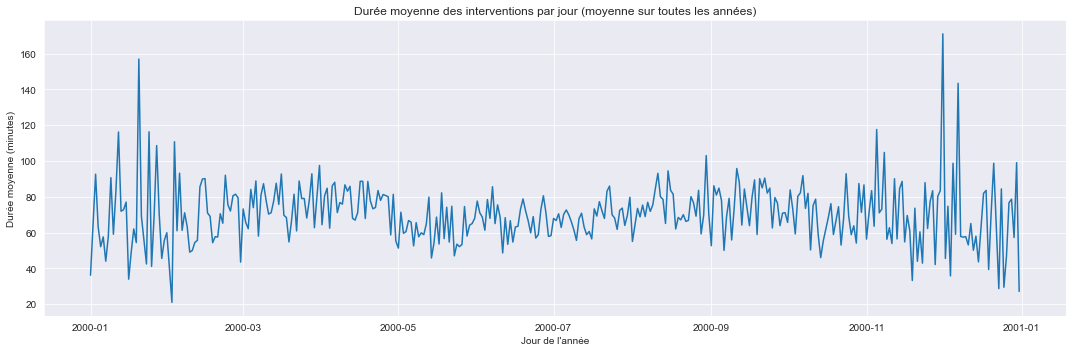

In [53]:
all_data_final['jour_mois'] = all_data_final['date'].dt.strftime('%m-%d')

df_moyen_jour = all_data_final.groupby('jour_mois')['duree_minutes'].mean().reset_index()

df_moyen_jour['date_fictive'] = pd.to_datetime('2000-' + df_moyen_jour['jour_mois'], format='%Y-%m-%d')

df_moyen_jour = df_moyen_jour.sort_values('date_fictive')

plt.figure(figsize=(15, 5))
sns.lineplot(data=df_moyen_jour, x='date_fictive', y='duree_minutes')
plt.title("Durée moyenne des interventions par jour (moyenne sur toutes les années)")
plt.ylabel("Durée moyenne (minutes)")
plt.xlabel("Jour de l'année")
plt.grid(True)
plt.tight_layout()
plt.show()

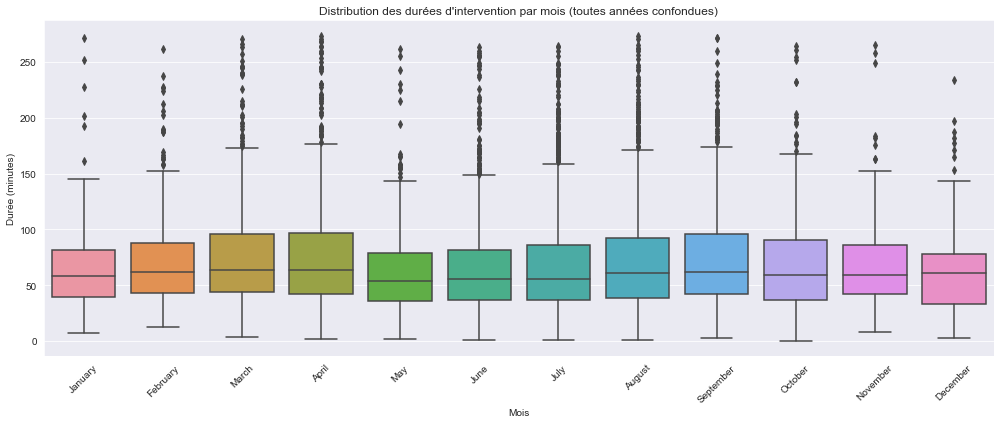

In [54]:
all_data_final['mois'] = all_data_final['date'].dt.month_name()

mois_order = ['January', 'February', 'March', 'April', 'May', 'June',
              'July', 'August', 'September', 'October', 'November', 'December']

plt.figure(figsize=(14, 6))
sns.boxplot(data=all_data_final, x='mois', y='duree_minutes', order=mois_order)
plt.title("Distribution des durées d'intervention par mois (toutes années confondues)")
plt.ylabel("Durée (minutes)")
plt.xlabel("Mois")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

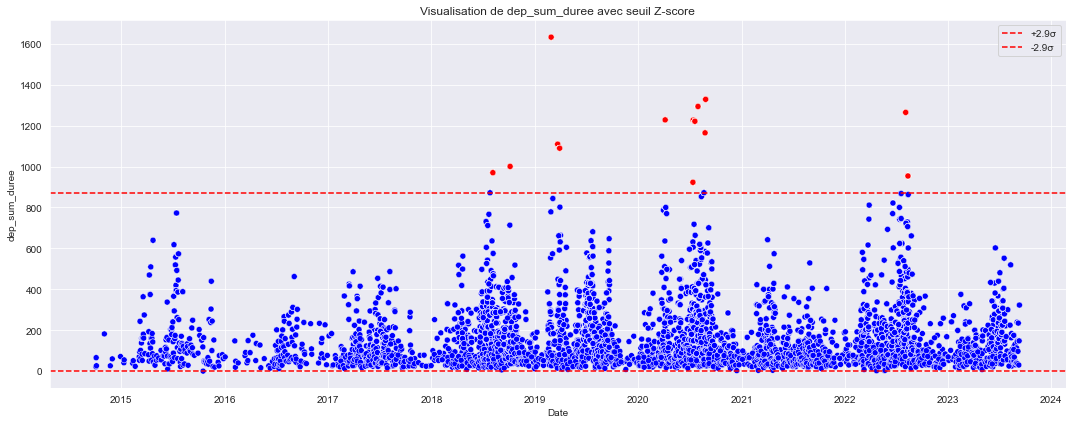

In [55]:
all_data_final['z_score'] = zscore(all_data_final['dep_sum_duree'])

seuil = 2.9

plt.figure(figsize=(15, 6))
sns.scatterplot(
    data=all_data_final.sort_values('date'),
    x='date',
    y='dep_sum_duree',
    hue=all_data_final['z_score'].abs() > seuil,
    palette={True: 'red', False: 'blue'},
    legend=False
)

z_limite_sup = all_data_final.loc[all_data_final['z_score'] <= seuil, 'dep_sum_duree'].max()
z_limite_inf = all_data_final.loc[all_data_final['z_score'] >= -seuil, 'dep_sum_duree'].min()

plt.axhline(z_limite_sup, color='red', linestyle='--', label=f'+{seuil}σ')
plt.axhline(z_limite_inf, color='red', linestyle='--', label=f'-{seuil}σ')

plt.title("Visualisation de dep_sum_duree avec seuil Z-score")
plt.xlabel("Date")
plt.ylabel("dep_sum_duree")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [56]:
seuil = 2.9

all_data_Z = all_data_final[all_data_final['z_score'].abs() <= seuil].copy()

In [57]:
unique_hex_ids = all_data_Z['hex_id'].unique()
np.random.seed(42)
np.random.shuffle(unique_hex_ids)

train_hex, temp_hex = train_test_split(unique_hex_ids, test_size=0.30, random_state=42)
valid_hex, test_hex = train_test_split(temp_hex, test_size=0.50, random_state=42)

esg_train = all_data_Z[all_data_Z['hex_id'].isin(train_hex)]
esg_valid = all_data_Z[all_data_Z['hex_id'].isin(valid_hex)]
esg_test = all_data_Z[all_data_Z['hex_id'].isin(test_hex)]

print(f"Train: {len(esg_train)} ({len(esg_train) / len(all_data_Z) * 100:.1f}%)")
print(f"Validation: {len(esg_valid)} ({len(esg_valid) / len(all_data_Z) * 100:.1f}%)")
print(f"Test: {len(esg_test)} ({len(esg_test) / len(all_data_Z) * 100:.1f}%)")

colonnes_a_exclure = ['hex_id', 'geometry', 'centroid', 'hex_voisins', 'year', 'duree_minutes', 'z_score', "dep_sum_duree", "date", "mois", "jour_mois"]

features = [col for col in all_data_Z.columns if col not in colonnes_a_exclure]

X_train, y_train = esg_train[features], esg_train["dep_sum_duree"]
X_valid, y_valid = esg_valid[features], esg_valid["dep_sum_duree"]
X_test, y_test = esg_test[features], esg_test["dep_sum_duree"]

print(f"Features utilisées : {features}")

Train: 4954 (68.2%)
Validation: 1086 (14.9%)
Test: 1229 (16.9%)
Features utilisées : ['departement', 'centroid_lon', 'centroid_lat', 'hour', 'month', 'weekday', 'NDVI', 'NDMI', 'NDBI', 'NDSI', 'NDWI', 'PasDeRoute', 'motorway', 'primary', 'secondary', 'tertiary', 'path', 'population', 'elevation', 'foret_encoder', 'highway_encoder', 'PasDeforet', 'Châtaignier', 'Chênes décidus', 'Conifères', 'Douglas', 'Feuillus', 'Hêtre', 'Mixte', 'Mélèze', 'NC', 'NR', 'Peuplier', 'Pin autre', 'Pin laricio, pin noir', 'Pin maritime', 'Pin sylvestre', 'Pins mélangés', 'Robinier', 'Sapin, épicéa', 'water', 'tree', 'grass', 'crops', 'shrub', 'flooded', 'built', 'bare', 'snow', 'pop_x_route', 'NDVI_NDMI', 'NDWI_NDSI', 'elev_x_foret', 'log_population', 'sqrt_elevation', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'weekday_sin', 'weekday_cos', 'mean_duree_hex_7j', 'std_duree_hex_7j']


In [58]:
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), ['departement']),
        ('num', StandardScaler(), [col for col in features if col != 'departement'])
    ]
)

preprocessor.fit(X_train)

X_train_preprocessed = preprocessor.transform(X_train)
X_valid_preprocessed = preprocessor.transform(X_valid)
X_test_preprocessed = preprocessor.transform(X_test)

In [59]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42),
    "CatBoost": CatBoostRegressor(verbose=0, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, random_state=42),
    "LightGBM": LGBMRegressor(n_estimators=100, random_state=42)
}

def evaluate_model(name, model, X_train, y_train, X_valid, y_valid, X_test, y_test):
    model.fit(X_train, y_train)

    y_pred_test = model.predict(X_test)
    y_pred_valid = model.predict(X_valid)

    metrics = {
        "Model": name,
        "Val RMSE": np.sqrt(mean_squared_error(y_valid, y_pred_valid)),
        "Test RMSE": np.sqrt(mean_squared_error(y_test, y_pred_test)),
        "Test MAE": mean_absolute_error(y_test, y_pred_test),
        "Test R²": r2_score(y_test, y_pred_test)
    }
    return metrics

results = []
for name, model in models.items():
    metrics = evaluate_model(name, model,
                             X_train_preprocessed, y_train,
                             X_valid_preprocessed, y_valid,
                             X_test_preprocessed, y_test)
    results.append(metrics)

results_df = pd.DataFrame(results).sort_values(by="Test R²", ascending=False)
print("Comparaison des modèles :")
print(results_df)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003340 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 9921
[LightGBM] [Info] Number of data points in the train set: 4954, number of used features: 61
[LightGBM] [Info] Start training from score 237.358576
Comparaison des modèles :
               Model    Val RMSE   Test RMSE    Test MAE   Test R²
6           LightGBM  161.053609  165.745733  126.048560  0.219852
3  Gradient Boosting  159.817992  167.190954  127.885198  0.206188
4           CatBoost  161.774874  167.363087  127.986862  0.204552
2      Random Forest  162.050623  168.968075  129.833241  0.189223
5            XGBoost  170.404336  174.812051  134.351562  0.132169
1   Ridge Regression  166.919766  175.557337  134.231880  0.124754
0  Linear Regression  167.030551  175.612090  134.083514  0.124208


In [60]:
catboost_params = {
    'iterations': 1000,
    'learning_rate': 0.1,
    'depth': 6,
    'loss_function': 'RMSE',
    'eval_metric': 'RMSE',
    'random_seed': 42,
    'early_stopping_rounds': 10
}

catboost_model = CatBoostRegressor(**catboost_params)

catboost_model.fit(X_train_preprocessed, y_train,
                   eval_set=(X_valid_preprocessed, y_valid),
                   use_best_model=True)

y_pred_test_catboost = catboost_model.predict(X_test_preprocessed)
rmse_catboost = np.sqrt(mean_squared_error(y_test, y_pred_test_catboost))
print(f"CatBoost Test RMSE: {rmse_catboost:.4f}")
print(f"CatBoost Best Iteration: {catboost_model.get_best_iteration()}")

0:	learn: 180.3833682	test: 174.8244792	best: 174.8244792 (0)	total: 10.3ms	remaining: 10.3s
1:	learn: 177.7777068	test: 172.3200856	best: 172.3200856 (1)	total: 16.7ms	remaining: 8.35s
2:	learn: 176.2079249	test: 170.9709281	best: 170.9709281 (2)	total: 22.6ms	remaining: 7.51s
3:	learn: 174.4459120	test: 169.1438389	best: 169.1438389 (3)	total: 28.2ms	remaining: 7.03s
4:	learn: 172.9622833	test: 167.9073216	best: 167.9073216 (4)	total: 33.5ms	remaining: 6.66s
5:	learn: 171.5056012	test: 166.7517203	best: 166.7517203 (5)	total: 43.8ms	remaining: 7.25s
6:	learn: 170.2823701	test: 165.8182375	best: 165.8182375 (6)	total: 50.1ms	remaining: 7.1s
7:	learn: 169.4787115	test: 165.2727579	best: 165.2727579 (7)	total: 55.5ms	remaining: 6.88s
8:	learn: 168.7485134	test: 164.8150696	best: 164.8150696 (8)	total: 60.9ms	remaining: 6.71s
9:	learn: 168.1963231	test: 164.5475360	best: 164.5475360 (9)	total: 66.5ms	remaining: 6.58s
10:	learn: 167.4371093	test: 164.0532714	best: 164.0532714 (10)	total: 

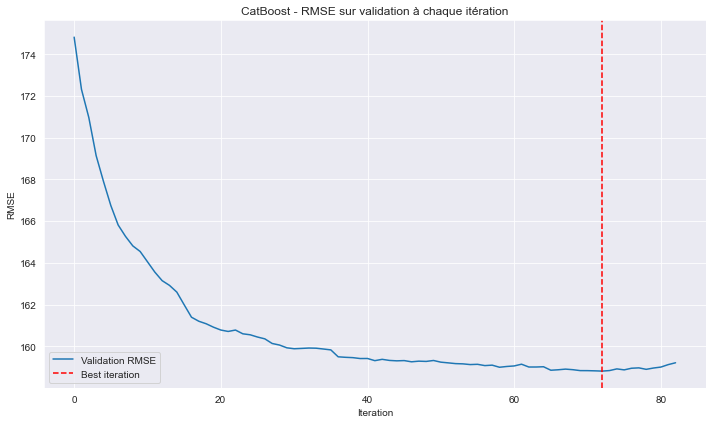

In [61]:
evals_result = catboost_model.get_evals_result()
plt.figure(figsize=(10, 6))
plt.plot(evals_result['validation']['RMSE'], label='Validation RMSE')
plt.xlabel("Iteration")
plt.ylabel("RMSE")
plt.title("CatBoost - RMSE sur validation à chaque itération")
plt.axvline(catboost_model.get_best_iteration(), color='r', linestyle='--', label='Best iteration')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

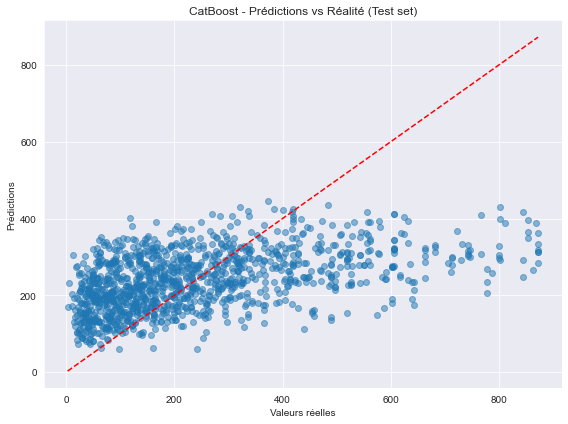

In [62]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_test_catboost, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Valeurs réelles")
plt.ylabel("Prédictions")
plt.title("CatBoost - Prédictions vs Réalité (Test set)")
plt.grid(True)
plt.tight_layout()
plt.show()

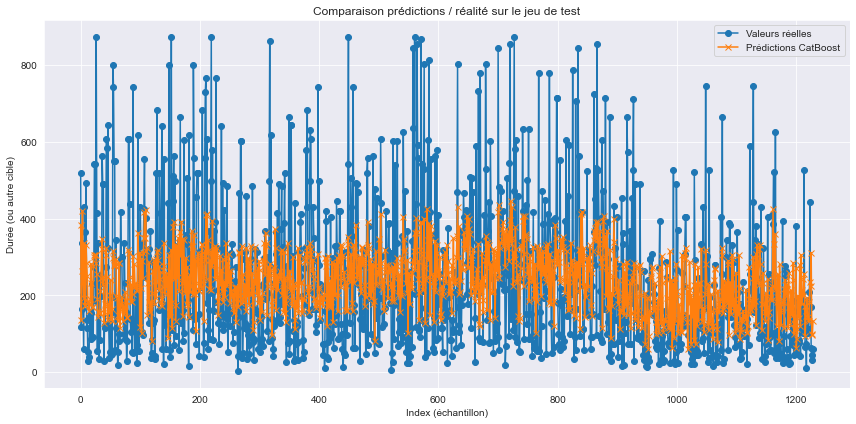

In [63]:
plt.figure(figsize=(12, 6))
plt.plot(y_test.values, label='Valeurs réelles', marker='o')
plt.plot(y_pred_test_catboost, label='Prédictions CatBoost', marker='x')
plt.title("Comparaison prédictions / réalité sur le jeu de test")
plt.xlabel("Index (échantillon)")
plt.ylabel("Durée (ou autre cible)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

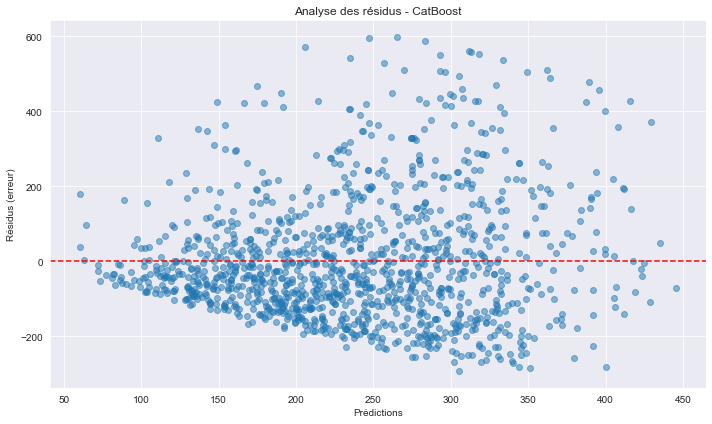

In [64]:
residuals = y_test - y_pred_test_catboost

plt.figure(figsize=(10, 6))
plt.scatter(y_pred_test_catboost, residuals, alpha=0.5)
plt.axhline(0, color='r', linestyle='--')
plt.xlabel("Prédictions")
plt.ylabel("Résidus (erreur)")
plt.title("Analyse des résidus - CatBoost")
plt.grid(True)
plt.tight_layout()
plt.show()

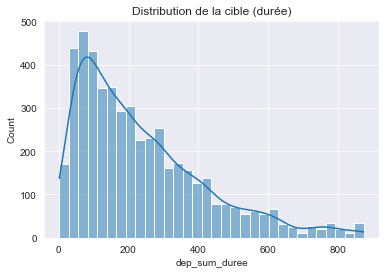

In [65]:
sns.histplot(y_train, kde=True)
plt.title("Distribution de la cible (durée)")
plt.show()

In [66]:
y_train_log = np.log1p(y_train)
y_valid_log = np.log1p(y_valid)
y_test_log = np.log1p(y_test)

catboost_model.fit(
    X_train_preprocessed, y_train_log,
    eval_set=(X_valid_preprocessed, y_valid_log),
    use_best_model=True,
    verbose=100
)

y_pred_test_log = catboost_model.predict(X_test_preprocessed)
y_pred_test = np.expm1(y_pred_test_log)

0:	learn: 0.8567694	test: 0.8565597	best: 0.8565597 (0)	total: 6.47ms	remaining: 6.47s
Stopped by overfitting detector  (10 iterations wait)

bestTest = 0.7757912009
bestIteration = 42

Shrink model to first 43 iterations.


In [67]:
rmse_transformed = np.sqrt(mean_squared_error(y_test, y_pred_test))
print(f"CatBoost RMSE après log-transform: {rmse_transformed:.2f}")

CatBoost RMSE après log-transform: 177.94


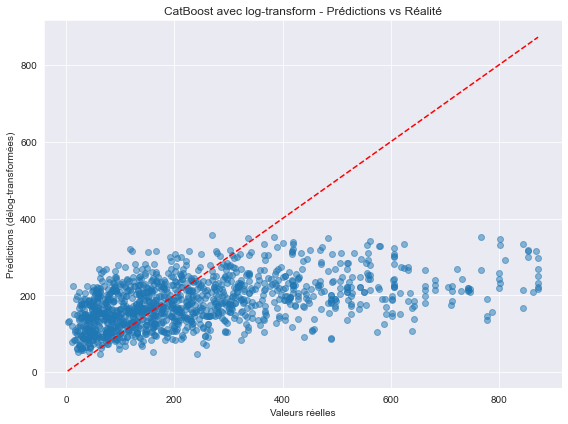

In [68]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_test, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Valeurs réelles")
plt.ylabel("Prédictions (délog-transformées)")
plt.title("CatBoost avec log-transform - Prédictions vs Réalité")
plt.grid(True)
plt.tight_layout()
plt.show()

In [69]:
sample_weights = np.log1p(y_train)

catboost_model.fit(
    X_train_preprocessed, y_train_log,
    sample_weight=sample_weights,
    eval_set=(X_valid_preprocessed, y_valid_log),
    use_best_model=True,
    verbose=100
)

y_pred_test_log = catboost_model.predict(X_test_preprocessed)
y_pred_test = np.expm1(y_pred_test_log)

rmse_weighted = np.sqrt(mean_squared_error(y_test, y_pred_test))
print(f"CatBoost RMSE avec log-transform + weighted loss: {rmse_weighted:.2f}")

0:	learn: 0.8126321	test: 0.8745408	best: 0.8745408 (0)	total: 5.8ms	remaining: 5.8s
100:	learn: 0.6755970	test: 0.7835728	best: 0.7835728 (100)	total: 523ms	remaining: 4.65s
Stopped by overfitting detector  (10 iterations wait)

bestTest = 0.7778905712
bestIteration = 170

Shrink model to first 171 iterations.
CatBoost RMSE avec log-transform + weighted loss: 169.38


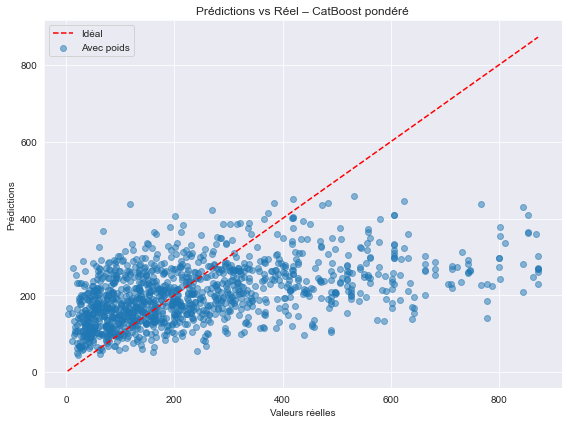

In [70]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_test, alpha=0.5, label='Avec poids')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Idéal')
plt.xlabel("Valeurs réelles")
plt.ylabel("Prédictions")
plt.title("Prédictions vs Réel – CatBoost pondéré")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [71]:
all_data_final.columns

Index(['hex_id', 'year', 'date', 'departement', 'duree_minutes', 'geometry',
       'centroid', 'centroid_lon', 'centroid_lat', 'hour', 'month', 'weekday',
       'NDVI', 'NDMI', 'NDBI', 'NDSI', 'NDWI', 'PasDeRoute', 'motorway',
       'primary', 'secondary', 'tertiary', 'path', 'population', 'elevation',
       'foret_encoder', 'highway_encoder', 'PasDeforet', 'Châtaignier',
       'Chênes décidus', 'Conifères', 'Douglas', 'Feuillus', 'Hêtre', 'Mixte',
       'Mélèze', 'NC', 'NR', 'Peuplier', 'Pin autre', 'Pin laricio, pin noir',
       'Pin maritime', 'Pin sylvestre', 'Pins mélangés', 'Robinier',
       'Sapin, épicéa', 'water', 'tree', 'grass', 'crops', 'shrub', 'flooded',
       'built', 'bare', 'snow', 'z_score', 'dep_sum_duree', 'pop_x_route',
       'NDVI_NDMI', 'NDWI_NDSI', 'elev_x_foret', 'log_population',
       'sqrt_elevation', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos',
       'weekday_sin', 'weekday_cos', 'mean_duree_hex_7j', 'std_duree_hex_7j',
       'jour_mois', 

In [72]:
dep_mean = all_data_Z.groupby("departement")["dep_sum_duree"].mean()
all_data_Z["mean_dep_duree"] = all_data_Z["departement"].map(dep_mean)

all_data_Z = all_data_Z.sort_values(by="date")
mean_past_hex = (
    all_data_Z
    .groupby("hex_id")["dep_sum_duree"]
    .expanding()
    .mean()
    .shift()
    .reset_index(level=0, drop=True)
)
all_data_Z["mean_hex_duree"] = mean_past_hex.fillna(0)

day_mean = all_data_Z.groupby("jour_mois")["dep_sum_duree"].mean()
all_data_Z["mean_jour_mois"] = all_data_Z["jour_mois"].map(day_mean)

long_durations = all_data_Z["dep_sum_duree"] > 400
long_freq_dep = long_durations.groupby(all_data_Z["departement"]).mean()
all_data_Z["freq_long_dep"] = all_data_Z["departement"].map(long_freq_dep)

all_data_Z["pop_density"] = all_data_Z["population"] / (all_data_Z["elevation"] + 1)

In [73]:
all_data_Z['rolling_mean_dep_7d'] = all_data_Z.groupby('departement')['dep_sum_duree'].rolling(7, min_periods=1).mean().reset_index(0, drop=True)

all_data_Z['rolling_mean_hex_30d'] = all_data_Z.groupby('hex_id')['dep_sum_duree'].rolling(30, min_periods=1).mean().reset_index(0, drop=True)

all_data_Z['month_hour_interaction'] = all_data_Z['month'] * all_data_Z['hour']

all_data_Z['month_weekday_interaction'] = all_data_Z['month'] * all_data_Z['weekday']

scaler = StandardScaler()
all_data_Z['population_scaled'] = scaler.fit_transform(all_data_Z[['population']])

long_durations = all_data_Z[all_data_Z['dep_sum_duree'] > 400]
long_durations_freq = long_durations.groupby('hex_id')['dep_sum_duree'].count() / all_data_Z.groupby('hex_id')['dep_sum_duree'].count()
all_data_Z['freq_long_hex'] = all_data_Z['hex_id'].map(long_durations_freq)

In [74]:
unique_hex_ids = all_data_Z['hex_id'].unique()
np.random.seed(42)
np.random.shuffle(unique_hex_ids)

train_hex, temp_hex = train_test_split(unique_hex_ids, test_size=0.30, random_state=42)
valid_hex, test_hex = train_test_split(temp_hex, test_size=0.50, random_state=42)

esg_train = all_data_Z[all_data_Z['hex_id'].isin(train_hex)]
esg_valid = all_data_Z[all_data_Z['hex_id'].isin(valid_hex)]
esg_test = all_data_Z[all_data_Z['hex_id'].isin(test_hex)]

print(f"Train: {len(esg_train)} ({len(esg_train) / len(all_data_Z) * 100:.1f}%)")
print(f"Validation: {len(esg_valid)} ({len(esg_valid) / len(all_data_Z) * 100:.1f}%)")
print(f"Test: {len(esg_test)} ({len(esg_test) / len(all_data_Z) * 100:.1f}%)")

colonnes_a_exclure = ['hex_id', 'geometry', 'centroid', 'hex_voisins', 'year', 'duree_minutes', 'z_score', "dep_sum_duree", "date", "mois", "jour_mois"]

features = [col for col in all_data_Z.columns if col not in colonnes_a_exclure]

X_train, y_train = esg_train[features], esg_train["dep_sum_duree"]
X_valid, y_valid = esg_valid[features], esg_valid["dep_sum_duree"]
X_test, y_test = esg_test[features], esg_test["dep_sum_duree"]

print(f"Features utilisées : {features}")

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), ['departement']),
        ('num', StandardScaler(), [col for col in features if col != 'departement'])
    ]
)

preprocessor.fit(X_train)

X_train_preprocessed = preprocessor.transform(X_train)
X_valid_preprocessed = preprocessor.transform(X_valid)
X_test_preprocessed = preprocessor.transform(X_test)

Train: 5025 (69.1%)
Validation: 1109 (15.3%)
Test: 1135 (15.6%)
Features utilisées : ['departement', 'centroid_lon', 'centroid_lat', 'hour', 'month', 'weekday', 'NDVI', 'NDMI', 'NDBI', 'NDSI', 'NDWI', 'PasDeRoute', 'motorway', 'primary', 'secondary', 'tertiary', 'path', 'population', 'elevation', 'foret_encoder', 'highway_encoder', 'PasDeforet', 'Châtaignier', 'Chênes décidus', 'Conifères', 'Douglas', 'Feuillus', 'Hêtre', 'Mixte', 'Mélèze', 'NC', 'NR', 'Peuplier', 'Pin autre', 'Pin laricio, pin noir', 'Pin maritime', 'Pin sylvestre', 'Pins mélangés', 'Robinier', 'Sapin, épicéa', 'water', 'tree', 'grass', 'crops', 'shrub', 'flooded', 'built', 'bare', 'snow', 'pop_x_route', 'NDVI_NDMI', 'NDWI_NDSI', 'elev_x_foret', 'log_population', 'sqrt_elevation', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'weekday_sin', 'weekday_cos', 'mean_duree_hex_7j', 'std_duree_hex_7j', 'mean_dep_duree', 'mean_hex_duree', 'mean_jour_mois', 'freq_long_dep', 'pop_density', 'rolling_mean_dep_7d', 'rolling_me

In [75]:
y_train_log = np.log1p(y_train)
y_valid_log = np.log1p(y_valid)
y_test_log = np.log1p(y_test)

catboost_model.fit(
    X_train_preprocessed, y_train_log,
    eval_set=(X_valid_preprocessed, y_valid_log),
    use_best_model=True,
    verbose=100
)

y_pred_test_log = catboost_model.predict(X_test_preprocessed)
y_pred_test = np.expm1(y_pred_test_log)

0:	learn: 0.8289249	test: 0.8287455	best: 0.8287455 (0)	total: 5.03ms	remaining: 5.03s
100:	learn: 0.4009244	test: 0.4614974	best: 0.4614974 (100)	total: 598ms	remaining: 5.32s
200:	learn: 0.3285953	test: 0.4255615	best: 0.4254558 (199)	total: 1.34s	remaining: 5.31s
300:	learn: 0.2867000	test: 0.4190140	best: 0.4190138 (299)	total: 2.11s	remaining: 4.89s
Stopped by overfitting detector  (10 iterations wait)

bestTest = 0.4153753072
bestIteration = 359

Shrink model to first 360 iterations.


In [76]:
rmse_transformed = np.sqrt(mean_squared_error(y_test, y_pred_test))
print(f"CatBoost RMSE après log-transform: {rmse_transformed:.2f}")

CatBoost RMSE après log-transform: 74.62


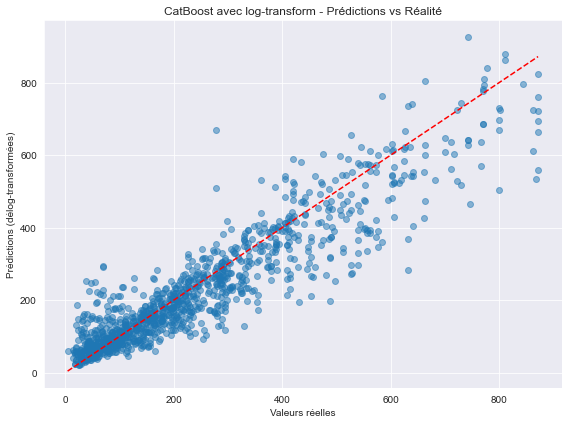

In [77]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_test, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Valeurs réelles")
plt.ylabel("Prédictions (délog-transformées)")
plt.title("CatBoost avec log-transform - Prédictions vs Réalité")
plt.grid(True)
plt.tight_layout()
plt.show()

In [78]:
sample_weights = np.log1p(y_train)

catboost_model.fit(
    X_train_preprocessed, y_train_log,
    sample_weight=sample_weights,
    eval_set=(X_valid_preprocessed, y_valid_log),
    use_best_model=True,
    verbose=100
)

y_pred_test_log = catboost_model.predict(X_test_preprocessed)
y_pred_test = np.expm1(y_pred_test_log)

rmse_weighted = np.sqrt(mean_squared_error(y_test, y_pred_test))
print(f"CatBoost RMSE avec log-transform + weighted loss: {rmse_weighted:.2f}")

0:	learn: 0.7895691	test: 0.8548870	best: 0.8548870 (0)	total: 6.56ms	remaining: 6.55s
100:	learn: 0.3917752	test: 0.4850229	best: 0.4850229 (100)	total: 815ms	remaining: 7.26s
200:	learn: 0.3098869	test: 0.4319640	best: 0.4319004 (199)	total: 1.55s	remaining: 6.17s
300:	learn: 0.2714879	test: 0.4189261	best: 0.4188438 (299)	total: 2.23s	remaining: 5.17s
Stopped by overfitting detector  (10 iterations wait)

bestTest = 0.4188438014
bestIteration = 299

Shrink model to first 300 iterations.
CatBoost RMSE avec log-transform + weighted loss: 71.58


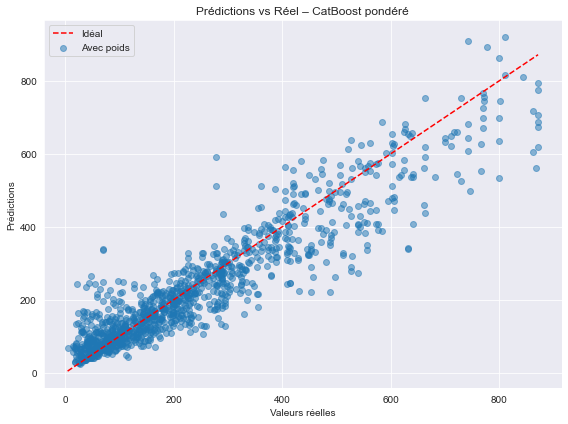

In [79]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_test, alpha=0.5, label='Avec poids')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Idéal')
plt.xlabel("Valeurs réelles")
plt.ylabel("Prédictions")
plt.title("Prédictions vs Réel – CatBoost pondéré")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [80]:
r2_catboost = r2_score(y_test, y_pred_test)
print(f"CatBoost Test R²: {r2_catboost:.4f}")

CatBoost Test R²: 0.8570


In [84]:
class CatBoostWrapper(BaseEstimator, RegressorMixin):
    def __init__(self, iterations=100, learning_rate=0.1, depth=6, l2_leaf_reg=3.0, bagging_temperature=1.0):
        self.iterations = iterations
        self.learning_rate = learning_rate
        self.depth = depth
        self.l2_leaf_reg = l2_leaf_reg
        self.bagging_temperature = bagging_temperature

    def fit(self, X, y):
        self.model = CatBoostRegressor(
            iterations=self.iterations,
            learning_rate=self.learning_rate,
            depth=self.depth,
            l2_leaf_reg=self.l2_leaf_reg,
            bagging_temperature=self.bagging_temperature,
            loss_function="RMSE",
            random_seed=42
        )

        self.model.fit(
            X, y,
            eval_set=(X_valid_preprocessed, y_valid_log),
            early_stopping_rounds=10,
            verbose=0,
            use_best_model=True
        )
        return self

    def predict(self, X):
        return self.model.predict(X)

    def score(self, X, y):
        return self.model.score(X, y)

rmse_scorer = make_scorer(lambda y_true, y_pred: -np.sqrt(mean_squared_error(y_true, y_pred)))

param_dist = {
    'iterations': randint(100, 300),
    'learning_rate': uniform(0.01, 0.2),
    'depth': randint(4, 10),
    'l2_leaf_reg': uniform(1, 5),
    'bagging_temperature': uniform(0, 1),
}

search = RandomizedSearchCV(
    estimator=CatBoostWrapper(),
    param_distributions=param_dist,
    n_iter=50,
    cv=3,
    scoring=rmse_scorer,
    n_jobs=-1,
    verbose=2,
    random_state=42
)

search.fit(X_train_preprocessed, y_train_log)

best_model = search.best_estimator_.model
y_pred_log = best_model.predict(X_test_preprocessed)

rmse = np.sqrt(mean_squared_error(y_test_log, y_pred_log))
r2 = best_model.score(X_test_preprocessed, y_test_log)

print("Meilleurs hyperparamètres :", search.best_params_)
print(f"Optimized CatBoost Log RMSE: {rmse:.2f}")
print(f"Optimized CatBoost R²: {r2:.4f}")

Fitting 3 folds for each of 50 candidates, totalling 150 fits
Meilleurs hyperparamètres : {'bagging_temperature': 0.1788227092213288, 'depth': 6, 'iterations': 244, 'l2_leaf_reg': 2.540303959261946, 'learning_rate': 0.11850804611097986}
Optimized CatBoost Log RMSE: 0.42
Optimized CatBoost R²: 0.7752


In [82]:
"""Fitting 3 folds for each of 150 candidates, totalling 450 fits
Meilleurs hyperparamètres : {'bagging_temperature': 0.035942273796742086, 'depth': 4, 'iterations': 285, 'l2_leaf_reg': 3.713223173537883, 'learning_rate': 0.06730825042565688}
Optimized CatBoost Log RMSE: 0.61
Optimized CatBoost R²: 0.5116"""

"Fitting 3 folds for each of 150 candidates, totalling 450 fits\nMeilleurs hyperparamètres : {'bagging_temperature': 0.035942273796742086, 'depth': 4, 'iterations': 285, 'l2_leaf_reg': 3.713223173537883, 'learning_rate': 0.06730825042565688}\nOptimized CatBoost Log RMSE: 0.61\nOptimized CatBoost R²: 0.5116"